In [1]:
import os
import multiprocessing

num_cores = multiprocessing.cpu_count()
print(f"La máquina tiene {num_cores} núcleos disponibles.")
hilos_optimos = str(min(num_cores, 64)) 
print(f"Configurando OpenBLAS para usar {hilos_optimos} hilos máximos...")
os.environ['OPENBLAS_NUM_THREADS'] = hilos_optimos
os.environ['MKL_NUM_THREADS'] = hilos_optimos
os.environ['OMP_NUM_THREADS'] = hilos_optimos

La máquina tiene 224 núcleos disponibles.
Configurando OpenBLAS para usar 64 hilos máximos...


In [2]:
import numpy as np
import pandas as pd
import itertools
import json
from pathlib import Path
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, accuracy_score, recall_score,classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.combine import SMOTEENN
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
import gc

In [3]:
X = pd.read_pickle("Sets_Xy/X.pkl")
y = pd.read_pickle("Sets_Xy/y.pkl")

from sklearn.model_selection import train_test_split

#Division estratificada para muestras de cada clase a nivel de cada subset

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, 
    random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, 
    random_state=42)

#Encoding de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

mapeo_labels = pd.DataFrame({
    "label_original": le.classes_,
    "label_encoded": range(len(le.classes_))
})
print("Mapeo de etiquetas:\n", mapeo_labels)
class_names = le.classes_

Mapeo de etiquetas:
                label_original  label_encoded
0                      BENIGN              0
1                         Bot              1
2                        DDoS              2
3               DoS GoldenEye              3
4                    DoS Hulk              4
5            DoS Slowhttptest              5
6               DoS slowloris              6
7                 FTP-Patator              7
8                  Heartbleed              8
9                Infiltration              9
10                   PortScan             10
11                SSH-Patator             11
12    Web Attack  Brute Force             12
13  Web Attack  Sql Injection             13
14            Web Attack  XSS             14


In [4]:
import joblib

X_train_none = joblib.load("Sets_Oversampling_2/X_train_none.joblib")
y_train_none = joblib.load("Sets_Oversampling_2/y_train_none.joblib")

X_val = pd.read_pickle("Sets_Post_Scaled_Imp/X_val_scaled_bayesian.pkl")
y_val = pd.DataFrame(y_val)

X_test = pd.read_pickle("Sets_Post_Scaled_Imp/X_test_scaled_bayesian.pkl")
y_test = pd.DataFrame(y_test)

y_val_1d = y_val.values.ravel() if isinstance(y_val, pd.DataFrame) else y_val.ravel()
y_test_1d = y_test.values.ravel() if isinstance(y_test, pd.DataFrame) else y_test.ravel()


Analisis de Distribucion: ORIGINAL (NONE)
Total de muestras: 1,823,353
Número de clases: 15
Imbalance Ratio: 179125.12:1

 Clase  Conteo Porcentaje (%)
     0 1433001       78.5915%
     4  161751        8.8711%
    10  111251        6.1015%
     2   89619        4.9151%
     3    7205        0.3952%
     7    5557        0.3048%
    11    4128        0.2264%
     6    4057        0.2225%
     5    3849        0.2111%
     1    1376        0.0755%
    12    1055        0.0579%
    14     456        0.0250%
     9      25        0.0014%
    13      15        0.0008%
     8       8        0.0004%


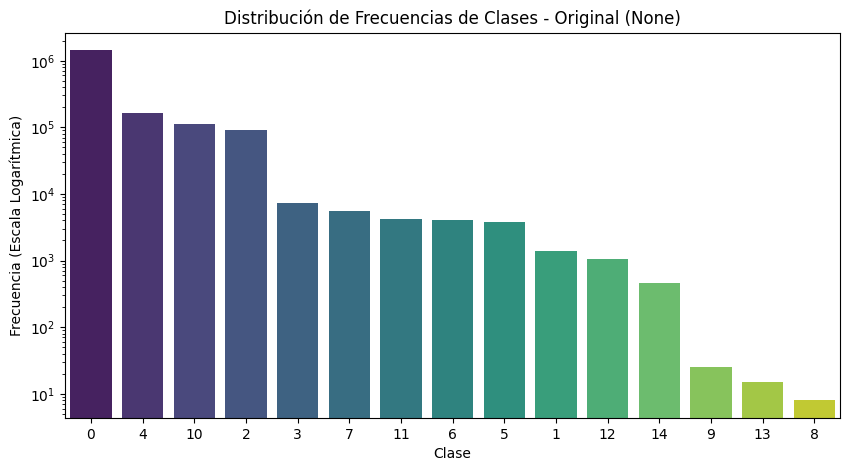

In [5]:
def analizar_distribuciones(y, nombre_dataset=""):
    total_muestras = len(y)
    classes, counts = np.unique(y, return_counts=True)
    
    sorted_idx = np.argsort(counts)[::-1]
    classes = classes[sorted_idx]
    counts = counts[sorted_idx]
    
    majority_count = counts[0]
    minority_count = counts[-1]
    imbalance_ratio = majority_count / minority_count
    
    print(f"Analisis de Distribucion: {nombre_dataset.upper()}")
    print(f"Total de muestras: {total_muestras:,}")
    print(f"Número de clases: {len(classes)}")
    print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1\n")
    
    porcentajes = (counts / total_muestras) * 100
    df_dist = pd.DataFrame({
        'Clase': classes,
        'Conteo': counts,
        'Porcentaje (%)': porcentajes
    })
    
    df_dist['Porcentaje (%)'] = df_dist['Porcentaje (%)'].map('{:.4f}%'.format)
    
    print(df_dist.to_string(index=False))
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=[str(c) for c in classes], y=counts, palette="viridis", hue=[str(c) for c in classes], legend=False)
    plt.title(f"Distribución de Frecuencias de Clases - {nombre_dataset}")
    plt.xlabel("Clase")
    plt.ylabel("Frecuencia (Escala Logarítmica)")
    plt.yscale('log')
    plt.show()
    
    return classes, counts

classes, counts = analizar_distribuciones(y_train_none, "Original (None)")

In [8]:
import numpy as np
import pandas as pd
import joblib
import os
from collections import Counter

X_train_base = joblib.load("Sets_Oversampling_2/X_train_none.joblib")
y_train_base = joblib.load("Sets_Oversampling_2/y_train_none.joblib")

if isinstance(y_train_base, pd.DataFrame) or isinstance(y_train_base, pd.Series):
    y_train_base = y_train_base.values.ravel()

CLASE_BENIGNA = 0
clases_experto_1 = [0]                
clases_experto_2 = [2, 4, 10]         
clases_experto_3 = [3, 5, 6, 7, 11]   
clases_experto_4 = [1]                
clases_experto_5 = [12, 13, 14]       
clases_experto_6 = [8, 9]             

os.makedirs("Sets_Expertos_MoE", exist_ok=True)

def predecir_tamano_post_smote(y_objetivo, target_large=200000):
    counts = Counter(y_objetivo)
    total_futuro = 0
    
    for cls, cnt in counts.items():
        if cls == CLASE_BENIGNA:
            total_futuro += cnt
        elif cnt < 1000: 
            total_futuro += cnt * 5     
        elif cnt < 5000:
            total_futuro += cnt * 10
        elif cnt < 10000:
            total_futuro += cnt * 20
        else:
            total_futuro += max(cnt, target_large)
            
    return total_futuro

def estratificar_con_minimo(X_pool, y_pool, n_samples):
    counts = Counter(y_pool)
    total_pool = len(y_pool)
    unique_classes = list(counts.keys())

    if n_samples >= total_pool:
        return X_pool, y_pool

    target_counts = {cls: 1 for cls in unique_classes}
    restantes = n_samples - len(unique_classes)

    for cls in unique_classes:
        prop = counts[cls] / total_pool
        adicionales = int(np.floor(restantes * prop))
        target_counts[cls] += adicionales
        target_counts[cls] = min(target_counts[cls], counts[cls])

    actual_total = sum(target_counts.values())
    faltantes = n_samples - actual_total

    if faltantes > 0:
        clases_ordenadas = sorted(unique_classes, key=lambda c: counts[c], reverse=True)
        for cls in clases_ordenadas:
            if faltantes == 0:
                break
            espacio_disponible = counts[cls] - target_counts[cls]
            if espacio_disponible > 0:
                agregar = min(faltantes, espacio_disponible)
                target_counts[cls] += agregar
                faltantes -= agregar

    indices_muestreados = []
    rng = np.random.default_rng(42)
    
    for cls, t_count in target_counts.items():
        idx_clase = np.where(y_pool == cls)[0]
        seleccion = rng.choice(idx_clase, size=t_count, replace=False)
        indices_muestreados.extend(seleccion)

    rng.shuffle(indices_muestreados)

    if hasattr(X_pool, 'iloc'):
        X_sample = X_pool.iloc[indices_muestreados]
    else:
        X_sample = X_pool[indices_muestreados]

    y_sample = y_pool[indices_muestreados]

    return X_sample, y_sample

def generar_subset_experto_exacto(X, y, clases_objetivo, clase_benigna=0, nombre_experto="Experto"):
    mask_objetivo = np.isin(y, clases_objetivo)
    X_objetivo = X[mask_objetivo]
    y_objetivo = y[mask_objetivo]
    
    mask_ruido = ~np.isin(y, clases_objetivo)
    X_ruido_pool = X[mask_ruido]
    y_ruido_pool = y[mask_ruido]
    
    tamano_objetivo_futuro = predecir_tamano_post_smote(y_objetivo)
    
    n_ruido = tamano_objetivo_futuro
    n_ruido = min(n_ruido, len(y_ruido_pool))
    
    if n_ruido > 0:
        if n_ruido == len(y_ruido_pool):
            X_ruido_sample = X_ruido_pool
            y_ruido_sample = y_ruido_pool
        else:
            X_ruido_sample, y_ruido_sample = estratificar_con_minimo(X_ruido_pool, y_ruido_pool, n_samples=n_ruido)
        
        if hasattr(X, 'iloc'):
            X_final = pd.concat([X_objetivo, X_ruido_sample], axis=0)
        else:
            X_final = np.vstack((X_objetivo, X_ruido_sample))
        y_final = np.concatenate([y_objetivo, y_ruido_sample])
    else:
        X_final = X_objetivo
        y_final = y_objetivo

    joblib.dump(X_final, f"Sets_Expertos_MoE/X_train_{nombre_experto}.joblib")
    joblib.dump(y_final, f"Sets_Expertos_MoE/y_train_{nombre_experto}.joblib")
    
    print(f"{nombre_experto.upper()}")
    muestras_objetivo_actual = len(y_objetivo)
    muestras_ruido_actual = len(y_final) - muestras_objetivo_actual
    
    print(f"Estado Antes de SMOTE:")
    print(f"Objetivo: {muestras_objetivo_actual:,} | Ruido inyectado: {muestras_ruido_actual:,}")
    
    total_futuro = tamano_objetivo_futuro + n_ruido
    pct_obj = (tamano_objetivo_futuro / total_futuro) * 100
    pct_ruido = (n_ruido / total_futuro) * 100
    
    print(f"Estado Post-SMOTE:")
    print(f"Objetivo: {tamano_objetivo_futuro:,} ({pct_obj:.2f}%) | Ruido: {n_ruido:,} ({pct_ruido:.2f}%)\n")
    
    return X_final, y_final

print("Generando subsets para entrenamiento de expertos de Mixture of Experts...\n")

X_e1, y_e1 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_1, nombre_experto="E1_Benigno")
X_e2, y_e2 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_2, nombre_experto="E2_Mayoritarios")
X_e3, y_e3 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_3, nombre_experto="E3_Medios")
X_e4, y_e4 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_4, nombre_experto="E4_Bot")
X_e5, y_e5 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_5, nombre_experto="E5_WebAttacks")
X_e6, y_e6 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_6, nombre_experto="E6_Minoritarios")

Generando subsets para entrenamiento de expertos de Mixture of Experts...

E1_BENIGNO
Estado Antes de SMOTE:
Objetivo: 1,433,001 | Ruido inyectado: 390,352
Estado Post-SMOTE:
Objetivo: 1,433,001 (78.59%) | Ruido: 390,352 (21.41%)

E2_MAYORITARIOS
Estado Antes de SMOTE:
Objetivo: 362,621 | Ruido inyectado: 600,000
Estado Post-SMOTE:
Objetivo: 600,000 (50.00%) | Ruido: 600,000 (50.00%)

E3_MEDIOS
Estado Antes de SMOTE:
Objetivo: 24,796 | Ruido inyectado: 375,580
Estado Post-SMOTE:
Objetivo: 375,580 (50.00%) | Ruido: 375,580 (50.00%)

E4_BOT
Estado Antes de SMOTE:
Objetivo: 1,376 | Ruido inyectado: 13,760
Estado Post-SMOTE:
Objetivo: 13,760 (50.00%) | Ruido: 13,760 (50.00%)

E5_WEBATTACKS
Estado Antes de SMOTE:
Objetivo: 1,526 | Ruido inyectado: 12,905
Estado Post-SMOTE:
Objetivo: 12,905 (50.00%) | Ruido: 12,905 (50.00%)

E6_MINORITARIOS
Estado Antes de SMOTE:
Objetivo: 33 | Ruido inyectado: 165
Estado Post-SMOTE:
Objetivo: 165 (50.00%) | Ruido: 165 (50.00%)



In [9]:
from collections import Counter

def get_ids_proportions(y, clases_experto, target_large=200000):
    counts = Counter(y)
    majority_count = max(counts.values())
    proportion_dict = {}

    for cls, cnt in counts.items():
        if cls in clases_experto:
            if cnt == majority_count:
                proportion_dict[cls] = cnt
                continue
                
            elif cnt < 1000:
                proportion_dict[cls] = cnt * 5
                
            elif cnt < 5000:
                proportion_dict[cls] = cnt * 10
                
            elif cnt < 10000:
                proportion_dict[cls] = cnt * 20    
            else:
                proportion_dict[cls] = max(cnt, target_large)

    return proportion_dict

In [10]:
import joblib

proportion_dict_E2 = get_ids_proportions(y_train_base, clases_experto_2)
proportion_dict_E3 = get_ids_proportions(y_train_base, clases_experto_3)
proportion_dict_E4 = get_ids_proportions(y_train_base, clases_experto_4)
proportion_dict_E5 = get_ids_proportions(y_train_base, clases_experto_5)
proportion_dict_E6 = get_ids_proportions(y_train_base, clases_experto_6)

print("Diccionarios por sets para los expertos")
print(f"E2: {proportion_dict_E2}")
print(f"E3: {proportion_dict_E3}")
print(f"E4: {proportion_dict_E4}")
print(f"E5: {proportion_dict_E5}")
print(f"E6: {proportion_dict_E6}")

Diccionarios por sets para los expertos
E2: {np.int64(4): 200000, np.int64(2): 200000, np.int64(10): 200000}
E3: {np.int64(11): 41280, np.int64(3): 144100, np.int64(7): 111140, np.int64(6): 40570, np.int64(5): 38490}
E4: {np.int64(1): 13760}
E5: {np.int64(12): 10550, np.int64(14): 2280, np.int64(13): 75}
E6: {np.int64(9): 125, np.int64(8): 40}


In [11]:
class OversamplingWithArtifactAnalysis(BaseEstimator, TransformerMixin):

    def __init__(self, method='smote', proportion=None, random_state=42, n_neighbors=5, **kwargs):
        self.method = method
        self.proportion = proportion
        self.random_state = random_state
        self.n_neighbors = n_neighbors
        self.kwargs = kwargs
        
        self.oversampler_ = None
        self.artifacts_report_ = {}

    def fit(self, X, y=None):
        if self.method == 'none':
            return self

        if self.method == 'smote':
            self.oversampler_ = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
        elif self.method == 'smote_tomek':
            smote_base = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
            self.oversampler_ = SMOTETomek(
                sampling_strategy=self.proportion,
                smote=smote_base,
                random_state=self.random_state
            )
        elif self.method == 'smote_enn':
            smote_base = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
            self.oversampler_ = SMOTEENN(
                sampling_strategy=self.proportion,
                smote=smote_base,
                random_state=self.random_state
            )
        
        return self

    def fit_resample(self, X, y):
        feature_names = X.columns.tolist() if hasattr(X, 'columns') else None
        orig_counts = Counter(y)

        if self.method == 'none':
            self._generar_reporte_avanzado(X, y, X, y, orig_counts, orig_counts)
            return X, y

        self.fit(X, y)
        
        X_res, y_res = self.oversampler_.fit_resample(X, y)
        new_counts = Counter(y_res)
        
        self._generar_reporte_avanzado(X, y, X_res, y_res, orig_counts, new_counts)

        if feature_names:
            X_res = pd.DataFrame(X_res, columns=feature_names)
            
        return X_res, y_res

    def _generar_reporte_avanzado(self, X_orig, y_orig, X_res, y_res, orig_counts, new_counts):
        if hasattr(X_orig, 'values'): X_orig = X_orig.values
        if hasattr(y_orig, 'values'): y_orig = y_orig.values
        if hasattr(X_res, 'values'): X_res = X_res.values
        if hasattr(y_res, 'values'): y_res = y_res.values

        reporte = {
            'metodo': self.method,
            'proporcion_config': {str(k): int(v) for k, v in self.proportion.items()} if isinstance(self.proportion, dict) else self.proportion,
            'resumen': {
                'muestras_antes': int(sum(orig_counts.values())),
                'muestras_despues': int(sum(new_counts.values())),
                'incremento_total': int(sum(new_counts.values()) - sum(orig_counts.values()))
            },
            'distribucion_original': {str(k): int(v) for k, v in orig_counts.items()},
            'distribucion_final': {str(k): int(v) for k, v in new_counts.items()},
            'analisis_por_clase': {}
        }

        unique_classes = np.unique(y_orig)
        print(f"\nCalculando métricas de artefactos para: {self.method.upper()}...")

        n_orig_total = len(X_orig)
        if self.method == 'smote':
            X_synth_global = X_res[n_orig_total:]
            y_synth_global = y_res[n_orig_total:]

        for clase in unique_classes:
            clase_str = str(clase)
            c_orig = orig_counts.get(clase, 0)
            c_new = new_counts.get(clase, 0)

            X_orig_c = X_orig[y_orig == clase]
            
            if self.method == 'smote':
                X_synth_c = X_synth_global[y_synth_global == clase]
            else:
                X_res_c = X_res[y_res == clase]
                if len(X_orig_c) > 0 and len(X_res_c) > 0:
                    nn_filter = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1).fit(X_orig_c)
                    dists, _ = nn_filter.kneighbors(X_res_c)
                    X_synth_c = X_res_c[dists.flatten() > 1e-6]
                else:
                    X_synth_c = np.array([])

            if c_new > c_orig: estado = "Oversampled"
            elif c_new < c_orig: estado = "Undersampled / Limpiado"
            else: estado = "Intacto"

            clase_info = {
                "estado": estado,
                "originales": int(c_orig),
                "finales": int(c_new),
                "sinteticas_puras_detectadas": int(len(X_synth_c)),
                "multiplicador": float(round(c_new / c_orig, 2)) if c_orig > 0 else 0.0
            }

            if len(X_orig_c) > 1 and len(X_synth_c) > 0 and estado != "Intacto":
                
                #Distancia interna original
                nn_baseline = NearestNeighbors(n_neighbors=2, metric='euclidean', n_jobs=-1)
                nn_baseline.fit(X_orig_c)
                dist_base, _ = nn_baseline.kneighbors(X_orig_c)
                mean_dist_base = float(np.mean(dist_base[:, 1]))

                #Distancia total de los datos nuevos hacia los originales
                nn_post = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
                nn_post.fit(X_orig_c)
                dist_post, _ = nn_post.kneighbors(X_synth_c)
                mean_dist_post = float(np.mean(dist_post))
                
                #Detectar duplicados exactos
                duplicados_pct = float(np.sum(dist_post < 1e-8) / len(dist_post) * 100)

                #Evaluación de Riesgo de Artefactos
                riesgo = "Bajo (Consistente)"
                if duplicados_pct > 5.0:
                    riesgo = f"Alto (Alerta de Duplicidad: {round(duplicados_pct, 1)}%)"
                elif mean_dist_base > 0 and (mean_dist_post > mean_dist_base * 2.5):
                    riesgo = "Alto (Artefactos Lejanos / Ruido)"

                clase_info["metricas_vecindario"] = {
                    "distancia_media_interna_original": float(round(mean_dist_base, 6)),
                    "distancia_media_sinteticos_a_originales": float(round(mean_dist_post, 6)),
                    "porcentaje_duplicados_exactos": float(round(duplicados_pct, 2)),
                    "riesgo_artefactos": riesgo
                }

            reporte['analisis_por_clase'][clase_str] = clase_info

        self.artifacts_report_ = reporte
        
        print(f"Análisis completado. Muestras: {reporte['resumen']['muestras_antes']} -> {reporte['resumen']['muestras_despues']}")
        
        for k, v in reporte['analisis_por_clase'].items():
            if 'metricas_vecindario' in v and "Alto" in v['metricas_vecindario']['riesgo_artefactos']:
                print(f"Precaución Clase {k}: {v['metricas_vecindario']['riesgo_artefactos']}")

    def transform(self, X):
        return X

    def get_artifacts_report(self):
        return self.artifacts_report_

    def save_report(self, filepath):
        with open(filepath, 'w') as f:
            json.dump(self.artifacts_report_, f, indent=2, default=str)

Analisis de Distribucion: SET-E2-PREVIO SMOTE
Total de muestras: 962,621
Número de clases: 15
Imbalance Ratio: 147150.75:1

 Clase  Conteo Porcentaje (%)
   0.0  588603       61.1459%
   4.0  161751       16.8032%
  10.0  111251       11.5571%
   2.0   89619        9.3099%
   3.0    2960        0.3075%
   7.0    2283        0.2372%
  11.0    1696        0.1762%
   6.0    1667        0.1732%
   5.0    1581        0.1642%
   1.0     566        0.0588%
  12.0     434        0.0451%
  14.0     188        0.0195%
   9.0      11        0.0011%
  13.0       7        0.0007%
   8.0       4        0.0004%


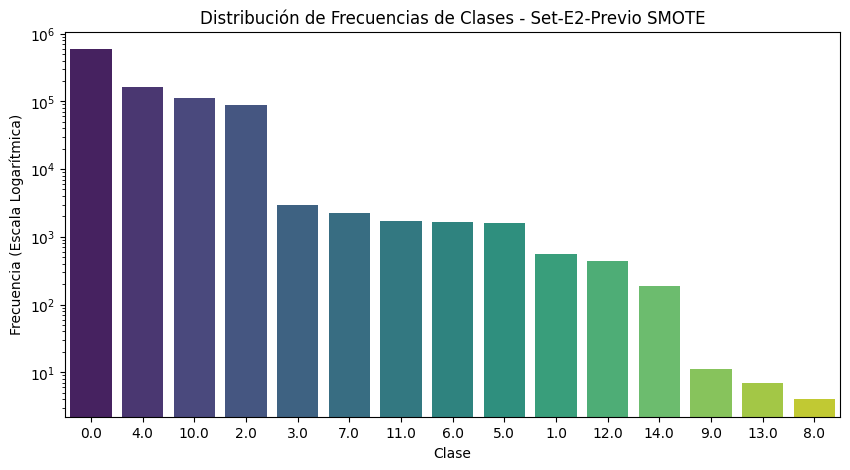

Analisis de Distribucion: SET-E3-PREVIO SMOTE
Total de muestras: 400,376
Número de clases: 15
Imbalance Ratio: 149619.50:1

 Clase  Conteo Porcentaje (%)
   0.0  299239       74.7395%
   4.0   33777        8.4363%
  10.0   23232        5.8025%
   2.0   18715        4.6744%
   3.0    7205        1.7996%
   7.0    5557        1.3879%
  11.0    4128        1.0310%
   6.0    4057        1.0133%
   5.0    3849        0.9613%
   1.0     288        0.0719%
  12.0     221        0.0552%
  14.0      96        0.0240%
   9.0       6        0.0015%
  13.0       4        0.0010%
   8.0       2        0.0005%


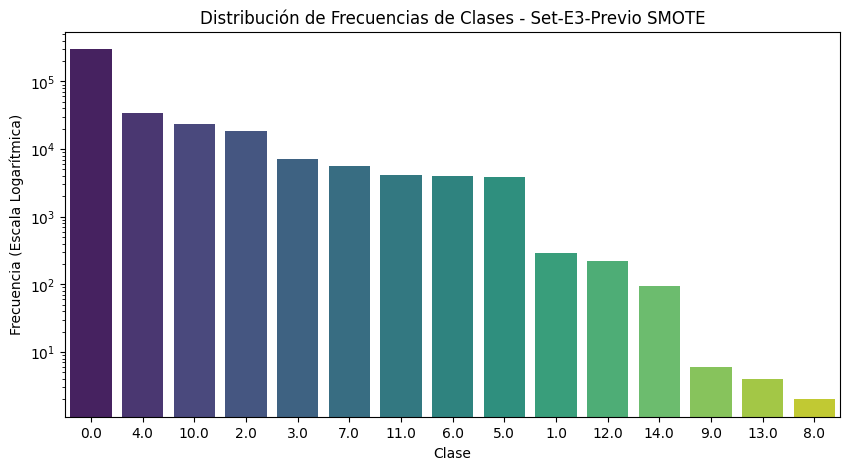

Analisis de Distribucion: SET-E4-PREVIO SMOTE
Total de muestras: 15,136
Número de clases: 15
Imbalance Ratio: 10817.00:1

 Clase  Conteo Porcentaje (%)
   0.0   10817       71.4654%
   1.0    1376        9.0909%
   4.0    1221        8.0669%
  10.0     840        5.5497%
   2.0     677        4.4728%
   3.0      55        0.3634%
   7.0      42        0.2775%
  11.0      32        0.2114%
   6.0      31        0.2048%
   5.0      30        0.1982%
  12.0       8        0.0529%
  14.0       4        0.0264%
   8.0       1        0.0066%
  13.0       1        0.0066%
   9.0       1        0.0066%


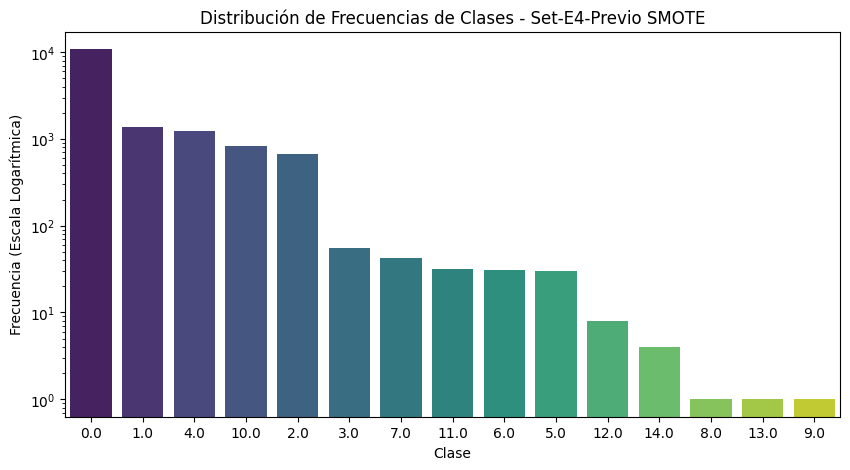

Analisis de Distribucion: SET-E5-PREVIO SMOTE
Total de muestras: 14,431
Número de clases: 15
Imbalance Ratio: 10147.00:1

 Clase  Conteo Porcentaje (%)
   0.0   10147       70.3139%
   4.0    1145        7.9343%
  12.0    1055        7.3107%
  10.0     788        5.4605%
   2.0     635        4.4002%
  14.0     456        3.1599%
   3.0      51        0.3534%
   7.0      40        0.2772%
  11.0      30        0.2079%
   6.0      29        0.2010%
   5.0      28        0.1940%
  13.0      15        0.1039%
   1.0      10        0.0693%
   8.0       1        0.0069%
   9.0       1        0.0069%


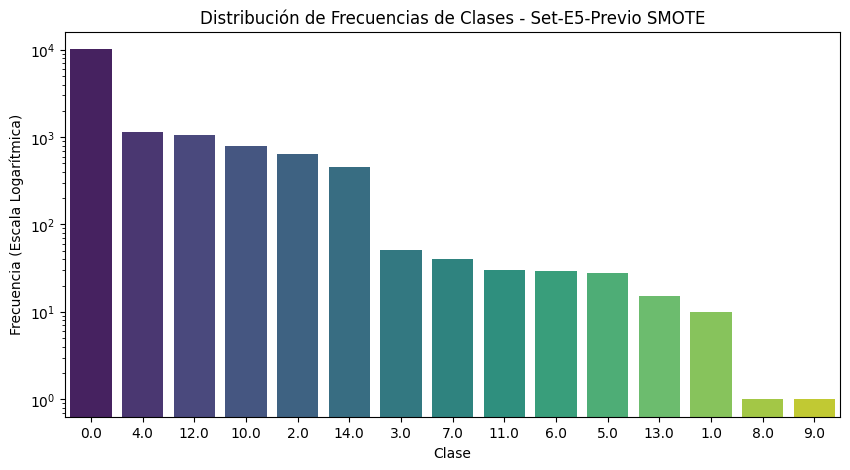

Analisis de Distribucion: SET-E6-PREVIO SMOTE
Total de muestras: 198
Número de clases: 15
Imbalance Ratio: 124.00:1

 Clase  Conteo Porcentaje (%)
   0.0     124       62.6263%
   9.0      25       12.6263%
   4.0      14        7.0707%
  10.0      10        5.0505%
   2.0       8        4.0404%
   8.0       8        4.0404%
  12.0       1        0.5051%
  11.0       1        0.5051%
  14.0       1        0.5051%
  13.0       1        0.5051%
   7.0       1        0.5051%
   5.0       1        0.5051%
   6.0       1        0.5051%
   3.0       1        0.5051%
   1.0       1        0.5051%


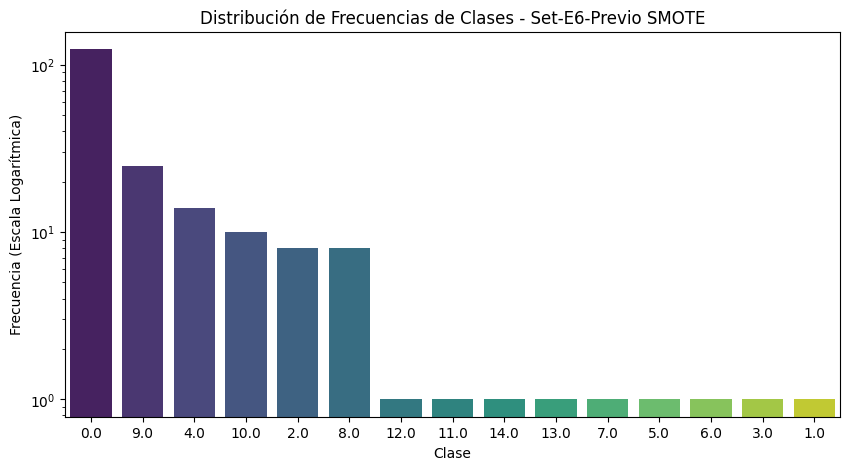

In [10]:
X_train_E2 = joblib.load("Sets_Expertos_MoE/X_train_E2_Mayoritarios.joblib").astype(np.float32)
y_train_E2 = joblib.load("Sets_Expertos_MoE/y_train_E2_Mayoritarios.joblib").astype(np.float32)
X_train_E3 = joblib.load("Sets_Expertos_MoE/X_train_E3_Medios.joblib").astype(np.float32)
y_train_E3 = joblib.load("Sets_Expertos_MoE/y_train_E3_Medios.joblib").astype(np.float32)
X_train_E4 = joblib.load("Sets_Expertos_MoE/X_train_E4_Bot.joblib").astype(np.float32)
y_train_E4 = joblib.load("Sets_Expertos_MoE/y_train_E4_Bot.joblib").astype(np.float32)
X_train_E5 = joblib.load("Sets_Expertos_MoE/X_train_E5_WebAttacks.joblib").astype(np.float32)
y_train_E5 = joblib.load("Sets_Expertos_MoE/y_train_E5_WebAttacks.joblib").astype(np.float32)
X_train_E6 = joblib.load("Sets_Expertos_MoE/X_train_E6_Minoritarios.joblib").astype(np.float32)
y_train_E6 = joblib.load("Sets_Expertos_MoE/y_train_E6_Minoritarios.joblib").astype(np.float32)

classes, counts = analizar_distribuciones(y_train_E2, "Set-E2-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E3, "Set-E3-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E4, "Set-E4-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E5, "Set-E5-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E6, "Set-E6-Previo SMOTE")


Iniciando método: NONE para set de experto 2
Finalizado: Datos originales mantenidos.

Iniciando método: SMOTE para set de experto 2

Calculando métricas de artefactos para: SMOTE...
Análisis completado. Muestras: 962621 -> 1200000
Precaución Clase 4.0: Alto (Alerta de Duplicidad: 6.8%)
Precaución Clase 10.0: Alto (Alerta de Duplicidad: 11.7%)
Finalizado con éxito. Nuevo tamaño: 1200000
Analisis de Distribucion: SET-E2-POST SMOTE
Total de muestras: 1,200,000
Número de clases: 15
Imbalance Ratio: 147150.75:1

 Clase  Conteo Porcentaje (%)
   0.0  588603       49.0502%
   4.0  200000       16.6667%
  10.0  200000       16.6667%
   2.0  200000       16.6667%
   3.0    2960        0.2467%
   7.0    2283        0.1903%
  11.0    1696        0.1413%
   6.0    1667        0.1389%
   5.0    1581        0.1318%
   1.0     566        0.0472%
  12.0     434        0.0362%
  14.0     188        0.0157%
   9.0      11        0.0009%
  13.0       7        0.0006%
   8.0       4        0.0003%


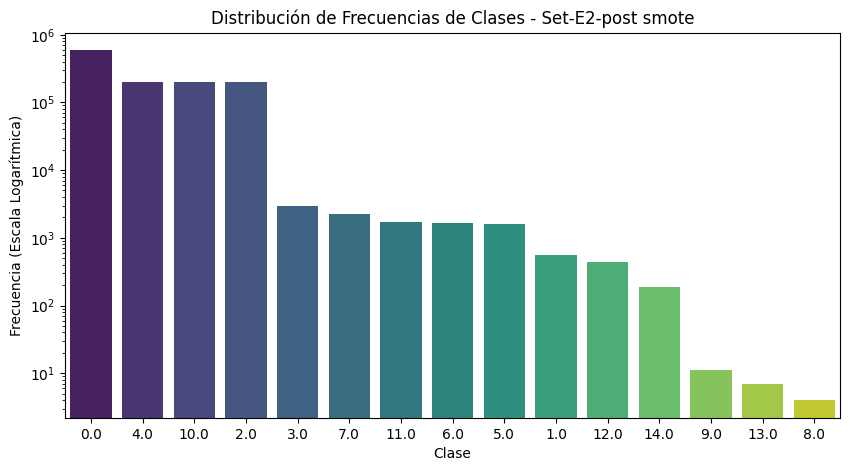


Iniciando método: SMOTE_ENN para set de experto 2

Calculando métricas de artefactos para: SMOTE_ENN...
Análisis completado. Muestras: 962621 -> 1195523
Finalizado con éxito. Nuevo tamaño: 1195523
Analisis de Distribucion: SET-E2-POST SMOTE_ENN
Total de muestras: 1,195,523
Número de clases: 14
Imbalance Ratio: 146633.00:1

 Clase  Conteo Porcentaje (%)
   0.0  586532       49.0607%
   2.0  199901       16.7208%
   4.0  199477       16.6853%
  10.0  199245       16.6659%
   3.0    2889        0.2417%
   7.0    2272        0.1900%
   6.0    1628        0.1362%
  11.0    1614        0.1350%
   5.0    1525        0.1276%
   1.0     232        0.0194%
  12.0     180        0.0151%
  14.0      20        0.0017%
   8.0       4        0.0003%
   9.0       4        0.0003%


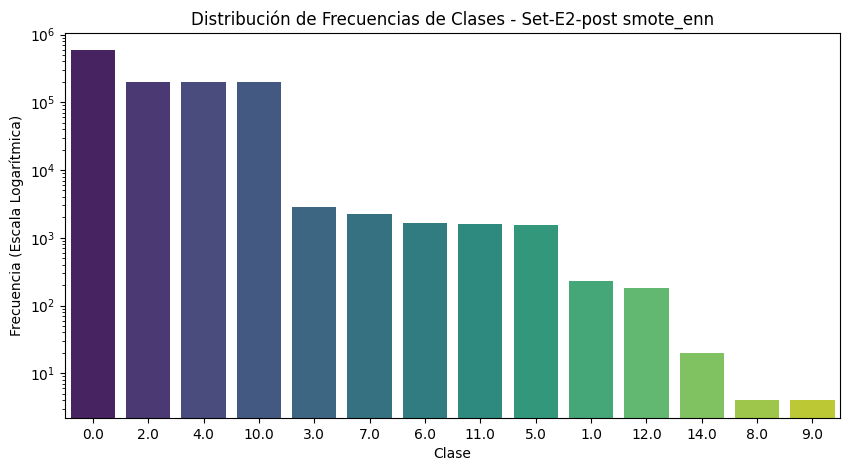


Iniciando método: SMOTE_TOMEK para set de experto 2

Calculando métricas de artefactos para: SMOTE_TOMEK...
Análisis completado. Muestras: 962621 -> 1199174
Finalizado con éxito. Nuevo tamaño: 1199174
Analisis de Distribucion: SET-E2-POST SMOTE_TOMEK
Total de muestras: 1,199,174
Número de clases: 15
Imbalance Ratio: 147074.50:1

 Clase  Conteo Porcentaje (%)
   0.0  588298       49.0586%
   2.0  199991       16.6774%
  10.0  199923       16.6717%
   4.0  199905       16.6702%
   3.0    2946        0.2457%
   7.0    2281        0.1902%
  11.0    1693        0.1412%
   6.0    1659        0.1383%
   5.0    1566        0.1306%
   1.0     426        0.0355%
  12.0     356        0.0297%
  14.0     112        0.0093%
   9.0       9        0.0008%
  13.0       5        0.0004%
   8.0       4        0.0003%


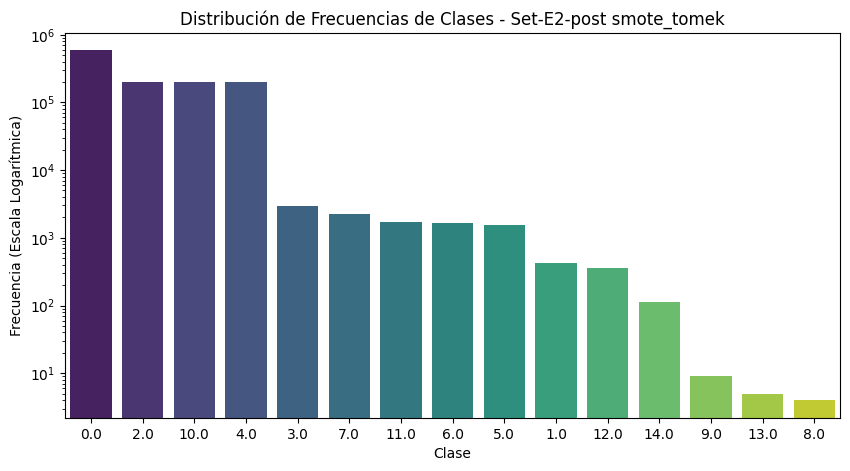


Iniciando método: NONE para set de experto 3
Finalizado: Datos originales mantenidos.

Iniciando método: SMOTE para set de experto 3

Calculando métricas de artefactos para: SMOTE...
Análisis completado. Muestras: 400376 -> 751160
Precaución Clase 5.0: Alto (Alerta de Duplicidad: 6.3%)
Finalizado con éxito. Nuevo tamaño: 751160
Analisis de Distribucion: SET-E3-POST SMOTE
Total de muestras: 751,160
Número de clases: 15
Imbalance Ratio: 149619.50:1

 Clase  Conteo Porcentaje (%)
   0.0  299239       39.8369%
   3.0  144100       19.1837%
   7.0  111140       14.7958%
  11.0   41280        5.4955%
   6.0   40570        5.4010%
   5.0   38490        5.1241%
   4.0   33777        4.4966%
  10.0   23232        3.0928%
   2.0   18715        2.4915%
   1.0     288        0.0383%
  12.0     221        0.0294%
  14.0      96        0.0128%
   9.0       6        0.0008%
  13.0       4        0.0005%
   8.0       2        0.0003%


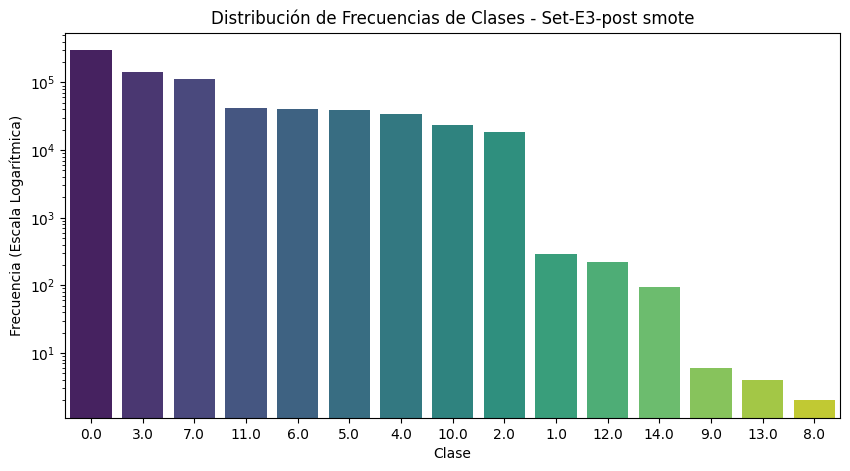


Iniciando método: SMOTE_ENN para set de experto 3

Calculando métricas de artefactos para: SMOTE_ENN...
Análisis completado. Muestras: 400376 -> 747699
Finalizado con éxito. Nuevo tamaño: 747699
Analisis de Distribucion: SET-E3-POST SMOTE_ENN
Total de muestras: 747,699
Número de clases: 12
Imbalance Ratio: 27084.82:1

 Clase  Conteo Porcentaje (%)
   0.0  297933       39.8466%
   3.0  144039       19.2643%
   7.0  111040       14.8509%
  11.0   41163        5.5053%
   6.0   40344        5.3958%
   5.0   38279        5.1196%
   4.0   33358        4.4614%
  10.0   22686        3.0341%
   2.0   18652        2.4946%
   1.0     107        0.0143%
  12.0      87        0.0116%
  14.0      11        0.0015%


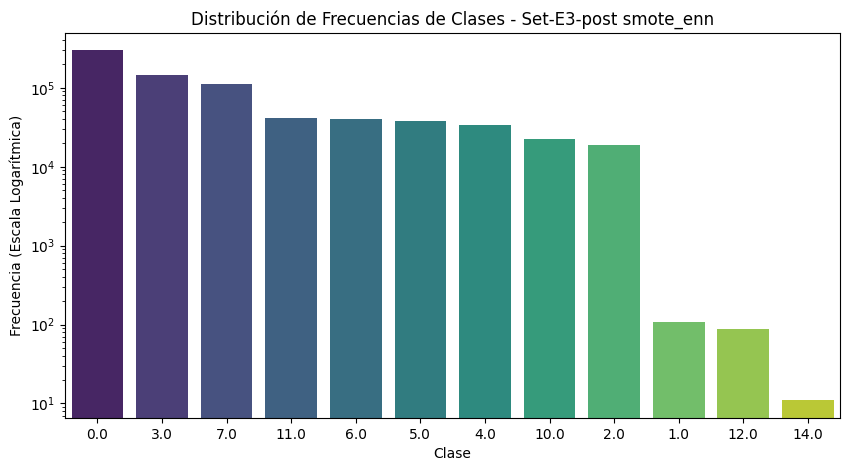


Iniciando método: SMOTE_TOMEK para set de experto 3

Calculando métricas de artefactos para: SMOTE_TOMEK...
Análisis completado. Muestras: 400376 -> 750424
Finalizado con éxito. Nuevo tamaño: 750424
Analisis de Distribucion: SET-E3-POST SMOTE_TOMEK
Total de muestras: 750,424
Número de clases: 15
Imbalance Ratio: 149495.00:1

 Clase  Conteo Porcentaje (%)
   0.0  298990       39.8428%
   3.0  144083       19.2002%
   7.0  111129       14.8088%
  11.0   41256        5.4977%
   6.0   40512        5.3985%
   5.0   38431        5.1212%
   4.0   33718        4.4932%
  10.0   23123        3.0813%
   2.0   18708        2.4930%
   1.0     220        0.0293%
  12.0     183        0.0244%
  14.0      62        0.0083%
   9.0       4        0.0005%
  13.0       3        0.0004%
   8.0       2        0.0003%


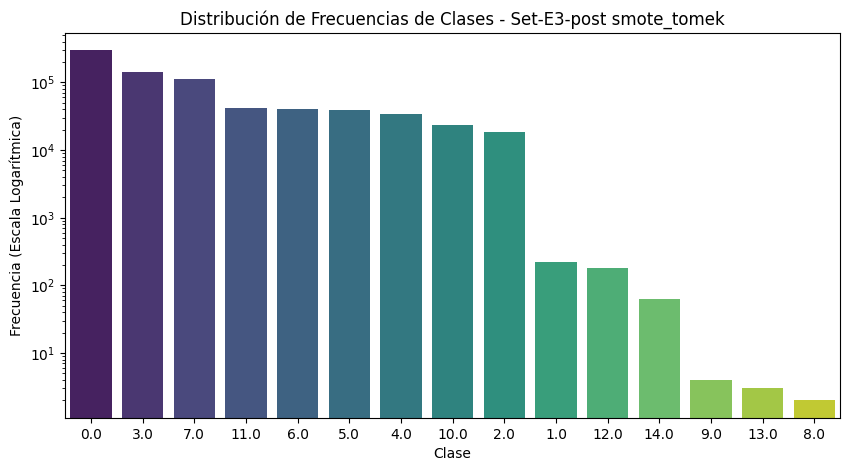


Iniciando método: NONE para set de experto 4
Finalizado: Datos originales mantenidos.

Iniciando método: SMOTE para set de experto 4

Calculando métricas de artefactos para: SMOTE...
Análisis completado. Muestras: 15136 -> 27520
Finalizado con éxito. Nuevo tamaño: 27520
Analisis de Distribucion: SET-E4-POST SMOTE
Total de muestras: 27,520
Número de clases: 15
Imbalance Ratio: 13760.00:1

 Clase  Conteo Porcentaje (%)
   1.0   13760       50.0000%
   0.0   10817       39.3060%
   4.0    1221        4.4368%
  10.0     840        3.0523%
   2.0     677        2.4600%
   3.0      55        0.1999%
   7.0      42        0.1526%
  11.0      32        0.1163%
   6.0      31        0.1126%
   5.0      30        0.1090%
  12.0       8        0.0291%
  14.0       4        0.0145%
   8.0       1        0.0036%
  13.0       1        0.0036%
   9.0       1        0.0036%


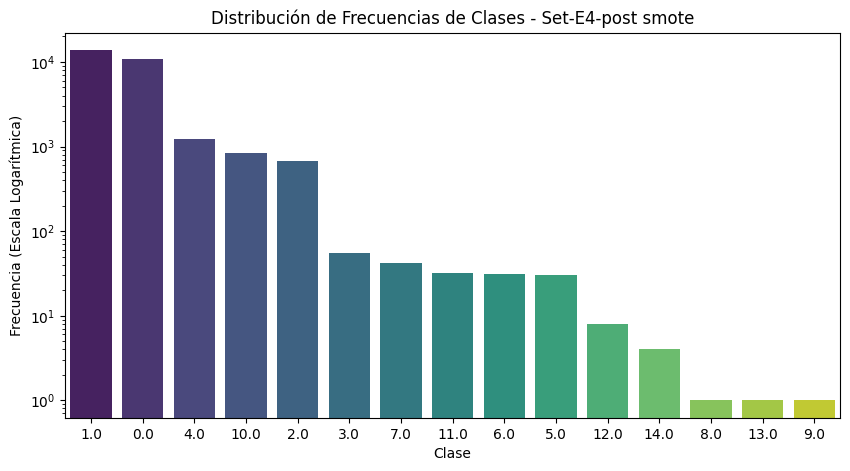


Iniciando método: SMOTE_ENN para set de experto 4

Calculando métricas de artefactos para: SMOTE_ENN...
Análisis completado. Muestras: 15136 -> 26874
Precaución Clase 0.0: Alto (Alerta de Duplicidad: 100.0%)
Finalizado con éxito. Nuevo tamaño: 26874
Analisis de Distribucion: SET-E4-POST SMOTE_ENN
Total de muestras: 26,874
Número de clases: 10
Imbalance Ratio: 621.18:1

 Clase  Conteo Porcentaje (%)
   1.0   13666       50.8521%
   0.0   10460       38.9224%
   4.0    1178        4.3834%
  10.0     747        2.7796%
   2.0     665        2.4745%
   3.0      40        0.1488%
   7.0      39        0.1451%
  11.0      31        0.1154%
   6.0      26        0.0967%
   5.0      22        0.0819%


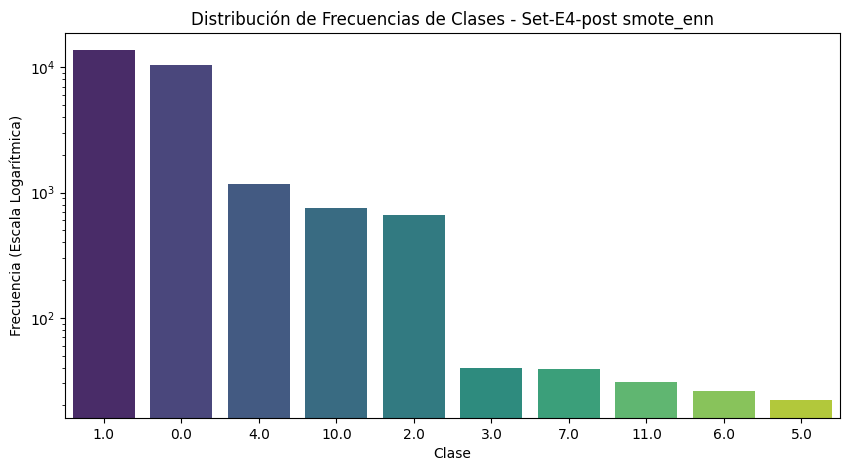


Iniciando método: SMOTE_TOMEK para set de experto 4

Calculando métricas de artefactos para: SMOTE_TOMEK...
Análisis completado. Muestras: 15136 -> 27424
Precaución Clase 0.0: Alto (Alerta de Duplicidad: 100.0%)
Finalizado con éxito. Nuevo tamaño: 27424
Analisis de Distribucion: SET-E4-POST SMOTE_TOMEK
Total de muestras: 27,424
Número de clases: 14
Imbalance Ratio: 13740.00:1

 Clase  Conteo Porcentaje (%)
   1.0   13740       50.1021%
   0.0   10771       39.2758%
   4.0    1216        4.4341%
  10.0     828        3.0193%
   2.0     677        2.4686%
   3.0      52        0.1896%
   7.0      42        0.1532%
  11.0      31        0.1130%
   6.0      31        0.1130%
   5.0      29        0.1057%
  12.0       4        0.0146%
   8.0       1        0.0036%
  14.0       1        0.0036%
  13.0       1        0.0036%


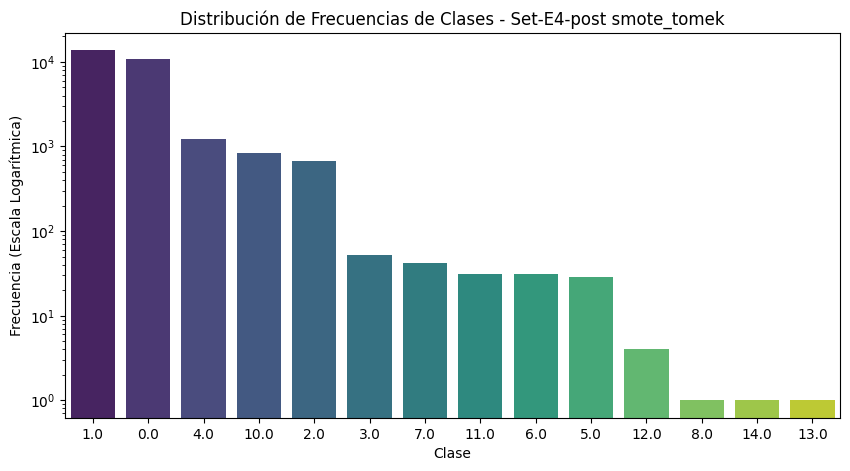


Iniciando método: NONE para set de experto 5
Finalizado: Datos originales mantenidos.

Iniciando método: SMOTE para set de experto 5

Calculando métricas de artefactos para: SMOTE...
Análisis completado. Muestras: 14431 -> 25810
Finalizado con éxito. Nuevo tamaño: 25810
Analisis de Distribucion: SET-E5-POST SMOTE
Total de muestras: 25,810
Número de clases: 15
Imbalance Ratio: 10550.00:1

 Clase  Conteo Porcentaje (%)
  12.0   10550       40.8756%
   0.0   10147       39.3142%
  14.0    2280        8.8338%
   4.0    1145        4.4363%
  10.0     788        3.0531%
   2.0     635        2.4603%
  13.0      75        0.2906%
   3.0      51        0.1976%
   7.0      40        0.1550%
  11.0      30        0.1162%
   6.0      29        0.1124%
   5.0      28        0.1085%
   1.0      10        0.0387%
   8.0       1        0.0039%
   9.0       1        0.0039%


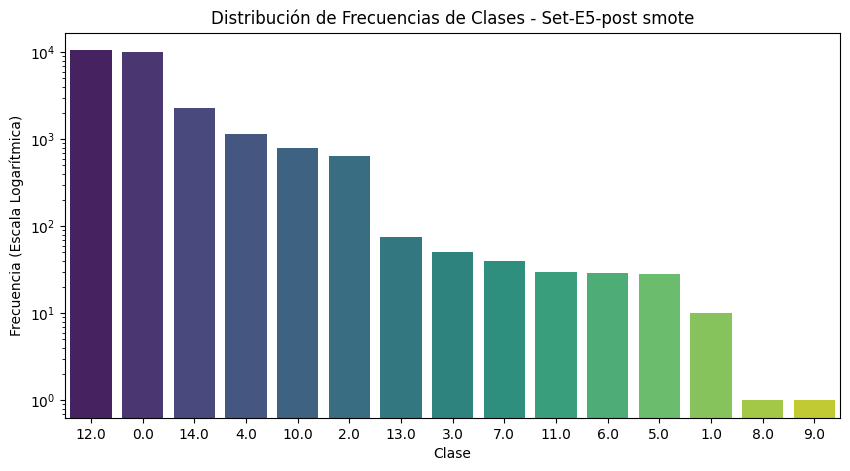


Iniciando método: SMOTE_ENN para set de experto 5

Calculando métricas de artefactos para: SMOTE_ENN...
Análisis completado. Muestras: 14431 -> 21928
Precaución Clase 0.0: Alto (Alerta de Duplicidad: 50.0%)
Precaución Clase 3.0: Alto (Alerta de Duplicidad: 100.0%)
Finalizado con éxito. Nuevo tamaño: 21928
Analisis de Distribucion: SET-E5-POST SMOTE_ENN
Total de muestras: 21,928
Número de clases: 13
Imbalance Ratio: 1653.83:1

 Clase  Conteo Porcentaje (%)
   0.0    9923       45.2526%
  12.0    8630       39.3561%
   4.0    1104        5.0347%
  14.0     760        3.4659%
  10.0     718        3.2744%
   2.0     618        2.8183%
  13.0      44        0.2007%
   3.0      36        0.1642%
   7.0      33        0.1505%
   5.0      21        0.0958%
   6.0      18        0.0821%
  11.0      17        0.0775%
   1.0       6        0.0274%


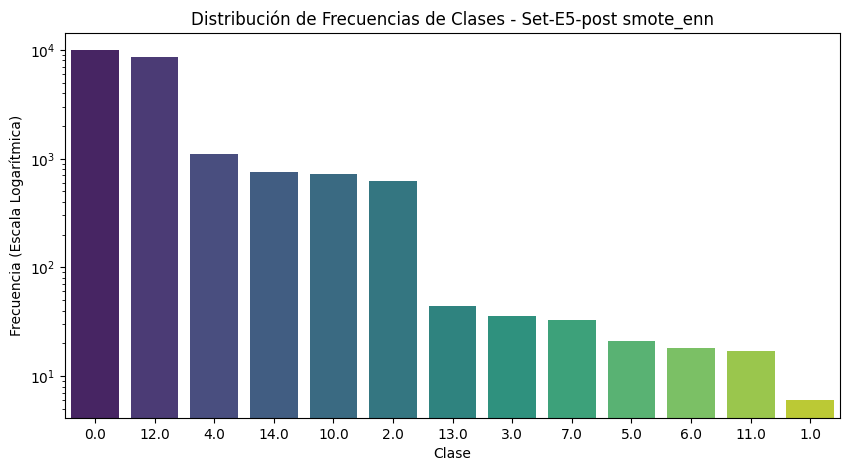


Iniciando método: SMOTE_TOMEK para set de experto 5

Calculando métricas de artefactos para: SMOTE_TOMEK...
Análisis completado. Muestras: 14431 -> 25032
Precaución Clase 0.0: Alto (Alerta de Duplicidad: 75.0%)
Precaución Clase 3.0: Alto (Alerta de Duplicidad: 100.0%)
Finalizado con éxito. Nuevo tamaño: 25032
Analisis de Distribucion: SET-E5-POST SMOTE_TOMEK
Total de muestras: 25,032
Número de clases: 14
Imbalance Ratio: 10183.00:1

 Clase  Conteo Porcentaje (%)
  12.0   10183       40.6799%
   0.0   10127       40.4562%
  14.0    1921        7.6742%
   4.0    1139        4.5502%
  10.0     776        3.1000%
   2.0     633        2.5288%
  13.0      66        0.2637%
   3.0      50        0.1997%
   7.0      40        0.1598%
  11.0      30        0.1198%
   6.0      29        0.1159%
   5.0      28        0.1119%
   1.0       9        0.0360%
   9.0       1        0.0040%


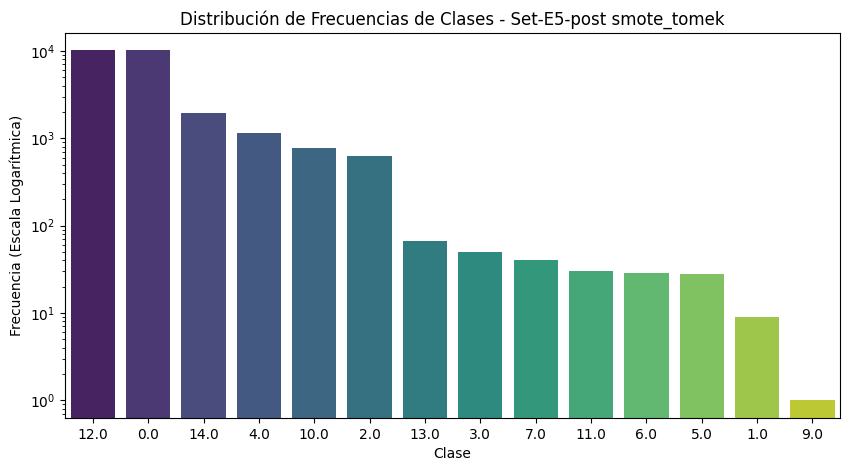


Iniciando método: NONE para set de experto 6
Finalizado: Datos originales mantenidos.

Iniciando método: SMOTE para set de experto 6

Calculando métricas de artefactos para: SMOTE...
Análisis completado. Muestras: 198 -> 330
Finalizado con éxito. Nuevo tamaño: 330
Analisis de Distribucion: SET-E6-POST SMOTE
Total de muestras: 330
Número de clases: 15
Imbalance Ratio: 125.00:1

 Clase  Conteo Porcentaje (%)
   9.0     125       37.8788%
   0.0     124       37.5758%
   8.0      40       12.1212%
   4.0      14        4.2424%
  10.0      10        3.0303%
   2.0       8        2.4242%
  12.0       1        0.3030%
  11.0       1        0.3030%
  14.0       1        0.3030%
  13.0       1        0.3030%
   7.0       1        0.3030%
   5.0       1        0.3030%
   6.0       1        0.3030%
   3.0       1        0.3030%
   1.0       1        0.3030%


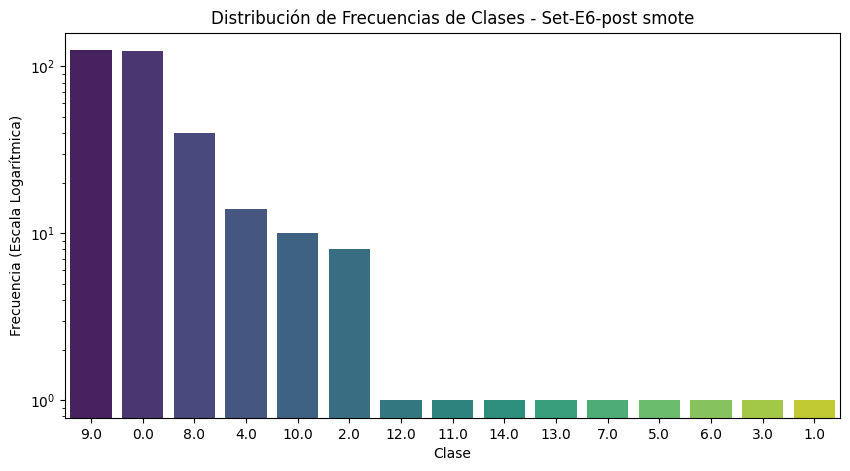


Iniciando método: SMOTE_ENN para set de experto 6

Calculando métricas de artefactos para: SMOTE_ENN...
Análisis completado. Muestras: 198 -> 268
Finalizado con éxito. Nuevo tamaño: 268
Analisis de Distribucion: SET-E6-POST SMOTE_ENN
Total de muestras: 268
Número de clases: 6
Imbalance Ratio: 38.67:1

 Clase  Conteo Porcentaje (%)
   9.0     116       43.2836%
   0.0      98       36.5672%
   8.0      40       14.9254%
   4.0       7        2.6119%
  10.0       4        1.4925%
   2.0       3        1.1194%


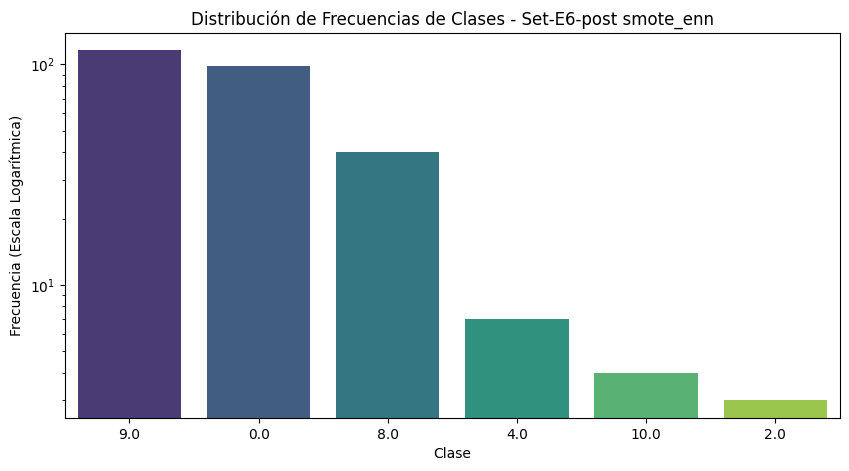


Iniciando método: SMOTE_TOMEK para set de experto 6

Calculando métricas de artefactos para: SMOTE_TOMEK...
Análisis completado. Muestras: 198 -> 320
Finalizado con éxito. Nuevo tamaño: 320
Analisis de Distribucion: SET-E6-POST SMOTE_TOMEK
Total de muestras: 320
Número de clases: 10
Imbalance Ratio: 124.00:1

 Clase  Conteo Porcentaje (%)
   9.0     124       38.7500%
   0.0     121       37.8125%
   8.0      40       12.5000%
   4.0      14        4.3750%
  10.0       9        2.8125%
   2.0       8        2.5000%
   5.0       1        0.3125%
   7.0       1        0.3125%
   3.0       1        0.3125%
   1.0       1        0.3125%


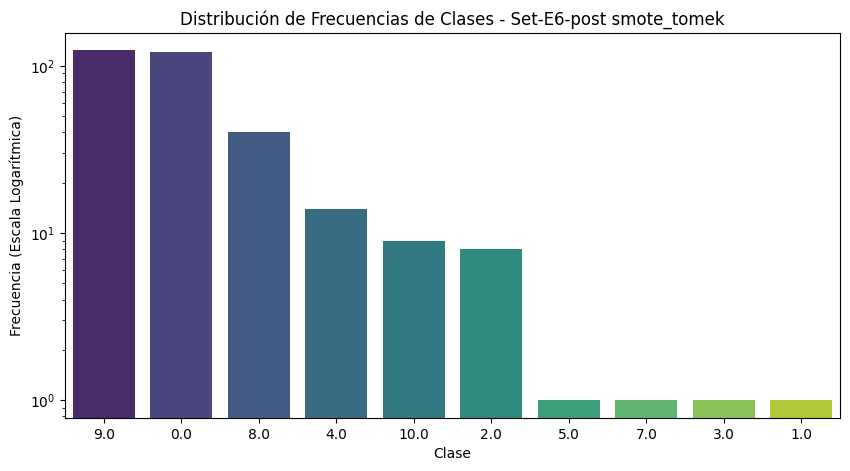

In [11]:
sets_moe= [[X_train_E2, y_train_E2, proportion_dict_E2],[X_train_E3, y_train_E3, proportion_dict_E3],[X_train_E4, y_train_E4, proportion_dict_E4],[X_train_E5, y_train_E5, proportion_dict_E5],[X_train_E6, y_train_E6, proportion_dict_E6]]
props_dicts_moe=[proportion_dict_E2,proportion_dict_E3,proportion_dict_E4,proportion_dict_E5,proportion_dict_E6]
oversampling_methods = ['none', 'smote', 'smote_enn', 'smote_tomek']
import gc

for i in range (len(sets_moe)):

    for over_method in oversampling_methods:
        print(f"\nIniciando método: {over_method.upper()} para set de experto {i+2}")
        
        X_train_input=sets_moe[i][0]
        y_train_input=sets_moe[i][1]

        if over_method == 'none':
            X_train_over, y_train_over = X_train_input, y_train_input
            joblib.dump(X_train_over, f"Sets_Oversampling_MoE/X_train_{over_method}_Experto_{i+2}.joblib")
            joblib.dump(y_train_over, f"Sets_Oversampling_MoE/y_train_{over_method}_Experto_{i+2}.joblib")
            print("Finalizado: Datos originales mantenidos.")
            continue
            
        oversampler = OversamplingWithArtifactAnalysis(
            method=over_method,
            proportion=props_dicts_moe[i],
            random_state=42,
            n_neighbors=5
        )
        
        try:
            X_train_over, y_train_over = oversampler.fit_resample(X_train_input, y_train_input)
            joblib.dump(X_train_over, f"Sets_Oversampling_MoE/X_train_{over_method}_Experto_{i+2}.joblib")
            joblib.dump(y_train_over, f"Sets_Oversampling_MoE/y_train_{over_method}_Experto_{i+2}.joblib")
            oversampler.save_report(f"artifacts_{over_method}_MoE_Experto_{i+2}.json")
            print(f"Finalizado con éxito. Nuevo tamaño: {len(y_train_over)}")

            classes, counts = analizar_distribuciones(y_train_over, f"Set-E{i+2}-post {over_method}")
            
        except ValueError as e:
            print(f"Advertencia: {over_method.upper()} falló en la interpolación.")
            print(f"Error reportado: {e}")
            print("Continuando con el siguiente método de la lista")
        
        del oversampler
        gc.collect()


In [12]:
import torch
import torch.nn as nn

class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout_rate, activation_name, num_classes=15):
        super().__init__()

        activations = {
            'leaky_relu': nn.LeakyReLU(0.01),
            'gelu': nn.GELU()
        }
        activation_layer = activations[activation_name]

        layers = []
        in_f = input_dim
        
        for out_f in hidden_layers:
            layers.append(nn.Linear(in_f, out_f))
            layers.append(nn.BatchNorm1d(out_f))
            layers.append(activation_layer)
            layers.append(nn.Dropout(dropout_rate))
            in_f = out_f
        
        layers.append(nn.Linear(in_f, num_classes))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x): 
        return self.net(x)

In [13]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import os
from functools import partial

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TensorDataLoader:
    
    def __init__(self, X, y, batch_size, shuffle=False):
        self.X = torch.tensor(X.values if hasattr(X, 'values') else X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.long).to(device)
        self.dataset_len = self.X.shape[0]
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __iter__(self):
        if self.shuffle:
            self.indices = torch.randperm(self.dataset_len, device=device)
        else:
            self.indices = None
        self.i = 0
        return self

    def __next__(self):
        if self.i >= self.dataset_len:
            raise StopIteration
        
        if self.indices is not None:
            idx = self.indices[self.i : self.i + self.batch_size]
            batch_X = self.X[idx]
            batch_y = self.y[idx]
        else:
            batch_X = self.X[self.i : self.i + self.batch_size]
            batch_y = self.y[self.i : self.i + self.batch_size]
            
        self.i += self.batch_size
        return batch_X, batch_y

    def __len__(self):
        return (self.dataset_len + self.batch_size - 1)

class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout_rate, activation_name, num_classes=15):
        super().__init__()
        activations = {
            'leaky_relu': nn.LeakyReLU(0.01),
            'gelu': nn.GELU(),
            'relu': nn.ReLU()
        }
        activation_layer = activations[activation_name]
        
        layers = []
        in_f = input_dim
        for out_f in hidden_layers:
            layers.append(nn.Linear(in_f, out_f))
            layers.append(nn.BatchNorm1d(out_f))
            layers.append(activation_layer)
            layers.append(nn.Dropout(dropout_rate))
            in_f = out_f
            
        layers.append(nn.Linear(in_f, num_classes))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x): 
        return self.net(x)
    
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        pt = torch.exp(-ce_loss)
        
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def objective(trial, X_train, y_train, X_val, y_val, input_dim, nombre_experto, clases_objetivo):
    batch_size = trial.suggest_categorical('batch_size', [4096, 8192, 16384])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    activation_name = trial.suggest_categorical('activation', ['leaky_relu', 'gelu'])
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    epochs = trial.suggest_int('epochs', 50, 100)
    focal_gamma = trial.suggest_float('focal_gamma', 0.0, 5.0)
    
    n_layers = trial.suggest_int('n_layers', 2, 4)
    shape_strategy = trial.suggest_categorical('mlp_shape', ['bottleneck', 'flat'])
    
    hidden_layers = []
    base_units = trial.suggest_int('n_units_l0', 256, 1024, step=256)
    hidden_layers.append(base_units)
    
    if shape_strategy == 'flat':
        for _ in range(1, n_layers):
            hidden_layers.append(base_units)
    else:
        prev_units = base_units
        for i in range(1, n_layers):
            units = trial.suggest_int(f'n_units_l{i}', 64, prev_units, step=64)
            hidden_layers.append(units)
            prev_units = units

    train_loader = TensorDataLoader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = TensorDataLoader(X_val, y_val, batch_size=batch_size*2, shuffle=False)

    model = TabularMLP(input_dim=input_dim, hidden_layers=hidden_layers, dropout_rate=dropout_rate, activation_name=activation_name).to(device)
    
    criterion = FocalLoss(gamma=focal_gamma)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
    scaler = torch.amp.GradScaler(device_type)

    best_macro_f1 = 0.0
    patience_counter = 0
    early_stopping_patience = 10
    best_model_state = None 
    
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            
            with torch.amp.autocast(device_type=device_type):
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
        model.eval()
        val_loss = 0.0
        y_true_list = []
        y_pred_list = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                with torch.amp.autocast(device_type=device_type):
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    
                val_loss += loss.item() * batch_X.size(0)
                _, preds = torch.max(outputs, 1)
                
                y_true_list.append(batch_y)
                y_pred_list.append(preds)
                
        y_true_all = torch.cat(y_true_list).cpu().numpy()
        y_pred_all = torch.cat(y_pred_list).cpu().numpy()
                
        val_loss = val_loss / len(val_loader)
        scheduler.step(val_loss)
        
        current_macro_f1 = f1_score(y_true_all, y_pred_all, labels=clases_objetivo, average='macro', zero_division=0)
    
        trial.report(current_macro_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
        if current_macro_f1 > best_macro_f1:
            best_macro_f1 = current_macro_f1
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= early_stopping_patience:
            break

    if best_model_state is not None:
        os.makedirs("Modelos_Expertos", exist_ok=True)
        ruta_guardado = f"Modelos_Expertos/{nombre_experto}_trial_{trial.number}.pth"
        torch.save(best_model_state, ruta_guardado)

    return best_macro_f1

In [14]:
!nvidia-smi

Mon Apr  6 16:00:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.20             Driver Version: 570.133.20     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H200                    On  |   00000000:1B:00.0 Off |                    0 |
| N/A   32C    P0            115W /  700W |    4027MiB / 143771MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [16]:
import optuna
import joblib
import gc
import numpy as np
from functools import partial

clases_por_experto = {
    1: [0],
    2: [2, 4, 10],
    3: [3, 5, 6, 7, 11],
    4: [1],
    5: [12, 13, 14],
    6: [8, 9]
}

print("Entrenamiento del Experto 1")
X_train_E1 = joblib.load("Sets_Expertos_MoE/X_train_E1_Benigno.joblib").astype(np.float32)
y_train_E1 = joblib.load("Sets_Expertos_MoE/y_train_E1_Benigno.joblib").astype(np.float32) 

input_dimension_E1 = X_train_E1.shape[1]
nombre_exp_1 = "Experto_1"

obj_func_1 = partial(
    objective, 
    X_train=X_train_E1, 
    y_train=y_train_E1, 
    X_val=X_val, 
    y_val=y_val_1d, 
    input_dim=input_dimension_E1,
    nombre_experto=nombre_exp_1,
    clases_objetivo=clases_por_experto[1] 
)

study_expert_1 = optuna.create_study(direction="maximize", study_name=nombre_exp_1)
study_expert_1.optimize(obj_func_1, n_trials=100)

print("\nResultados Entrenamiento Experto 1")
print(f"Mejor F1 Macro: {study_expert_1.best_value:.4f}")
print(f"Mejores Hiperparámetros:\n{study_expert_1.best_params}")
print(f"Mejor Trial: {study_expert_1.best_trial.number}")

del X_train_E1, y_train_E1
gc.collect()

Entrenamiento del Experto 1


[I 2026-04-06 16:06:09,439] A new study created in memory with name: Experto_1
[I 2026-04-06 16:06:38,789] Trial 0 finished with value: 0.9979102975260724 and parameters: {'batch_size': 8192, 'dropout_rate': 0.30662752062941256, 'activation': 'leaky_relu', 'lr': 0.001021068248023413, 'weight_decay': 0.0015047899709649487, 'epochs': 64, 'focal_gamma': 3.3696873384007158, 'n_layers': 3, 'mlp_shape': 'bottleneck', 'n_units_l0': 1024, 'n_units_l1': 960, 'n_units_l2': 768}. Best is trial 0 with value: 0.9979102975260724.
[I 2026-04-06 16:06:59,328] Trial 1 finished with value: 0.9978502188868043 and parameters: {'batch_size': 8192, 'dropout_rate': 0.4226468555690326, 'activation': 'gelu', 'lr': 0.0013105546780648432, 'weight_decay': 0.00122567598960318, 'epochs': 72, 'focal_gamma': 1.8032201984744485, 'n_layers': 3, 'mlp_shape': 'bottleneck', 'n_units_l0': 768, 'n_units_l1': 448, 'n_units_l2': 320}. Best is trial 0 with value: 0.9979102975260724.
[I 2026-04-06 16:07:10,753] Trial 2 finished


Resultados Entrenamiento Experto 1
Mejor F1 Macro: 0.9984
Mejores Hiperparámetros:
{'batch_size': 4096, 'dropout_rate': 0.4546740054368903, 'activation': 'leaky_relu', 'lr': 0.0010458860606448446, 'weight_decay': 3.2054745856858624e-05, 'epochs': 80, 'focal_gamma': 1.3836863896340441, 'n_layers': 3, 'mlp_shape': 'flat', 'n_units_l0': 768}
Mejor Trial: 79


2566

In [17]:
tipos_oversampling = ['smote', 'smote_tomek', 'smote_enn']

for tipo in tipos_oversampling:
    
    for i in range(2, 7):
        print(f"\nIniciando Entrenamiento Experto {i} con {tipo}...")
        
        X_train_input = joblib.load(f"Sets_Oversampling_MoE/X_train_{tipo}_Experto_{i}.joblib").astype(np.float32)
        y_train_input = joblib.load(f"Sets_Oversampling_MoE/y_train_{tipo}_Experto_{i}.joblib").astype(np.float32)
        
        input_dimension = X_train_input.shape[1]
        nombre_exp = f"Experto_{i}_{tipo}"

        obj_func = partial(
            objective, 
            X_train=X_train_input, 
            y_train=y_train_input, 
            X_val=X_val, 
            y_val=y_val_1d, 
            input_dim=input_dimension,
            nombre_experto=nombre_exp,
            clases_objetivo=clases_por_experto[i] 
        )

        study_expert = optuna.create_study(direction="maximize", study_name=nombre_exp)
        study_expert.optimize(obj_func, n_trials=100)

        print(f"Resultados Entrenamiento Experto {i} ({tipo})")
        print(f"Mejor F1 Macro: {study_expert.best_value:.4f}")
        print(f"Mejores Hiperparámetros:\n{study_expert.best_params}")
        print(f"Mejor Trial: {study_expert.best_trial.number}")
        
        del X_train_input, y_train_input, obj_func
        gc.collect()

print(f"\nEntrenamiento de todos los expertos finalizado")


Iniciando Entrenamiento Experto 2 con smote...


[I 2026-04-06 16:21:59,313] A new study created in memory with name: Experto_2_smote


[I 2026-04-06 16:22:09,405] Trial 0 finished with value: 0.9787614638746692 and parameters: {'batch_size': 8192, 'dropout_rate': 0.23962089256801677, 'activation': 'gelu', 'lr': 0.0001570785917053431, 'weight_decay': 5.155519580425384e-05, 'epochs': 51, 'focal_gamma': 0.6855288992962122, 'n_layers': 4, 'mlp_shape': 'bottleneck', 'n_units_l0': 256, 'n_units_l1': 256, 'n_units_l2': 256, 'n_units_l3': 64}. Best is trial 0 with value: 0.9787614638746692.
[I 2026-04-06 16:22:17,471] Trial 1 finished with value: 0.970294797429568 and parameters: {'batch_size': 4096, 'dropout_rate': 0.33812714721512327, 'activation': 'leaky_relu', 'lr': 0.0004634048173953394, 'weight_decay': 1.782917974794227e-05, 'epochs': 85, 'focal_gamma': 0.7670156612629847, 'n_layers': 3, 'mlp_shape': 'bottleneck', 'n_units_l0': 768, 'n_units_l1': 640, 'n_units_l2': 128}. Best is trial 0 with value: 0.9787614638746692.
[I 2026-04-06 16:22:57,515] Trial 2 finished with value: 0.9949372932903494 and parameters: {'batch_siz

Resultados Entrenamiento Experto 2 (smote)
Mejor F1 Macro: 0.9973
Mejores Hiperparámetros:
{'batch_size': 4096, 'dropout_rate': 0.1081658862089864, 'activation': 'leaky_relu', 'lr': 0.0011849105929172387, 'weight_decay': 0.0018643875776184564, 'epochs': 66, 'focal_gamma': 1.8666919614021853, 'n_layers': 4, 'mlp_shape': 'flat', 'n_units_l0': 1024}
Mejor Trial: 92

Iniciando Entrenamiento Experto 3 con smote...


[I 2026-04-06 16:39:47,457] A new study created in memory with name: Experto_3_smote
[I 2026-04-06 16:40:22,107] Trial 0 finished with value: 0.9595788549122612 and parameters: {'batch_size': 4096, 'dropout_rate': 0.1303073366267663, 'activation': 'gelu', 'lr': 0.00010690475841601363, 'weight_decay': 0.004235879732688405, 'epochs': 91, 'focal_gamma': 2.356007681855124, 'n_layers': 4, 'mlp_shape': 'bottleneck', 'n_units_l0': 1024, 'n_units_l1': 960, 'n_units_l2': 704, 'n_units_l3': 640}. Best is trial 0 with value: 0.9595788549122612.
[I 2026-04-06 16:40:50,408] Trial 1 finished with value: 0.9403155027115553 and parameters: {'batch_size': 8192, 'dropout_rate': 0.37785974841790193, 'activation': 'leaky_relu', 'lr': 0.00014189829207592145, 'weight_decay': 0.008225339256845257, 'epochs': 94, 'focal_gamma': 3.7381475553474584, 'n_layers': 4, 'mlp_shape': 'flat', 'n_units_l0': 1024}. Best is trial 0 with value: 0.9595788549122612.
[I 2026-04-06 16:41:06,717] Trial 2 finished with value: 0.9

...

Resultados Entrenamiento Experto 4 (smote_enn)
Mejor F1 Macro: 0.1821
Mejores Hiperparámetros:
{'batch_size': 4096, 'dropout_rate': 0.10185889336951198, 'activation': 'leaky_relu', 'lr': 0.0030719484241523167, 'weight_decay': 0.008135945939229358, 'epochs': 60, 'focal_gamma': 0.5643486158920079, 'n_layers': 3, 'mlp_shape': 'bottleneck', 'n_units_l0': 512, 'n_units_l1': 320, 'n_units_l2': 256}
Mejor Trial: 61

Iniciando Entrenamiento Experto 5 con smote_enn...


[I 2026-04-06 17:37:02,089] Trial 0 finished with value: 0.018159730357348983 and parameters: {'batch_size': 8192, 'dropout_rate': 0.2085117942729395, 'activation': 'gelu', 'lr': 0.00024841848840383515, 'weight_decay': 2.54604359251461e-06, 'epochs': 87, 'focal_gamma': 4.040224673162019, 'n_layers': 4, 'mlp_shape': 'flat', 'n_units_l0': 768}. Best is trial 0 with value: 0.018159730357348983.
[I 2026-04-06 17:37:04,245] Trial 1 finished with value: 0.06671266310970124 and parameters: {'batch_size': 8192, 'dropout_rate': 0.17420522255108684, 'activation': 'leaky_relu', 'lr': 0.004075759961639934, 'weight_decay': 6.753669145492256e-05, 'epochs': 55, 'focal_gamma': 2.9301962908798873, 'n_layers': 3, 'mlp_shape': 'flat', 'n_units_l0': 512}. Best is trial 1 with value: 0.06671266310970124.
[I 2026-04-06 17:37:06,193] Trial 2 finished with value: 0.035542974489657764 and parameters: {'batch_size': 16384, 'dropout_rate': 0.23554974607648083, 'activation': 'gelu', 'lr': 0.0006742189416328115, '

Resultados Entrenamiento Experto 5 (smote_enn)
Mejor F1 Macro: 0.0837
Mejores Hiperparámetros:
{'batch_size': 4096, 'dropout_rate': 0.33408187919615034, 'activation': 'leaky_relu', 'lr': 0.0036382412902831564, 'weight_decay': 9.621936016102766e-05, 'epochs': 57, 'focal_gamma': 1.3524753493185575, 'n_layers': 3, 'mlp_shape': 'flat', 'n_units_l0': 512}
Mejor Trial: 66

Iniciando Entrenamiento Experto 6 con smote_enn...


[I 2026-04-06 17:37:43,232] Trial 0 finished with value: 0.021897810218978103 and parameters: {'batch_size': 16384, 'dropout_rate': 0.26158691673802525, 'activation': 'leaky_relu', 'lr': 0.00034257952775126383, 'weight_decay': 9.721960410245358e-06, 'epochs': 83, 'focal_gamma': 2.266797798135772, 'n_layers': 4, 'mlp_shape': 'bottleneck', 'n_units_l0': 512, 'n_units_l1': 64, 'n_units_l2': 64, 'n_units_l3': 64}. Best is trial 0 with value: 0.021897810218978103.
[I 2026-04-06 17:37:43,844] Trial 1 finished with value: 0.2668920441739914 and parameters: {'batch_size': 4096, 'dropout_rate': 0.42818651852579215, 'activation': 'leaky_relu', 'lr': 0.0005783013418798738, 'weight_decay': 0.0001835656583438754, 'epochs': 67, 'focal_gamma': 3.253466573445261, 'n_layers': 4, 'mlp_shape': 'flat', 'n_units_l0': 512}. Best is trial 1 with value: 0.2668920441739914.
[I 2026-04-06 17:37:44,595] Trial 2 finished with value: 0.009846298906790374 and parameters: {'batch_size': 16384, 'dropout_rate': 0.2865

Resultados Entrenamiento Experto 6 (smote_enn)
Mejor F1 Macro: 0.3077
Mejores Hiperparámetros:
{'batch_size': 8192, 'dropout_rate': 0.49220209516561336, 'activation': 'leaky_relu', 'lr': 0.0001753050018695232, 'weight_decay': 1.1421419462873438e-05, 'epochs': 70, 'focal_gamma': 1.3557012979376506, 'n_layers': 4, 'mlp_shape': 'flat', 'n_units_l0': 256}
Mejor Trial: 89

Entrenamiento de todos los expertos finalizado


In [18]:
import optuna
import copy
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from functools import partial

class DynamicGatingNetwork(nn.Module):
    def __init__(self, input_dim, num_experts, hidden_layers, dropout_rate, activation_name):
        super(DynamicGatingNetwork, self).__init__()
        activations = {
            'leaky_relu': nn.LeakyReLU(0.01),
            'gelu': nn.GELU()
        }
        activation_layer = activations.get(activation_name, nn.LeakyReLU(0.01))
        
        layers = []
        in_f = input_dim
        for out_f in hidden_layers:
            layers.append(nn.Linear(in_f, out_f))
            layers.append(nn.BatchNorm1d(out_f))
            layers.append(activation_layer)
            layers.append(nn.Dropout(dropout_rate))
            in_f = out_f
            
        layers.append(nn.Linear(in_f, num_experts))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        logits = self.net(x)
        return torch.softmax(logits, dim=1)

class OptunaTabularMoE(nn.Module):
    def __init__(self, lista_expertos, gating_network):
        super(OptunaTabularMoE, self).__init__()
        self.experts = nn.ModuleList(lista_expertos)
        self.num_experts = len(self.experts)
        self.gating = gating_network

        # Congelo los pesos de todos los expertos para solo entrar el Gating
        for expert in self.experts:
            for param in expert.parameters():
                param.requires_grad = False

    def forward(self, x):
        pesos_gating = self.gating(x) 
        salidas_expertos = [expert(x) for expert in self.experts] 
        salidas_apiladas = torch.stack(salidas_expertos, dim=1) 
        
        pesos_gating = pesos_gating.unsqueeze(2) 
        salidas_ponderadas = salidas_apiladas * pesos_gating
        
        salida_final = torch.sum(salidas_ponderadas, dim=1) 
        return salida_final

def objective_gating(trial, X_train, y_train, X_val, y_val, input_dim, lista_expertos, oversampling):
    batch_size = trial.suggest_categorical('batch_size', [8192, 16384])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4)
    activation_name = trial.suggest_categorical('activation', ['leaky_relu', 'gelu'])
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_layers = []
    base_units = trial.suggest_int('n_units_l0', 64, 512, step=64)
    hidden_layers.append(base_units)
    
    prev_units = base_units
    for i in range(1, n_layers):
        units = trial.suggest_int(f'n_units_l{i}', 64, prev_units, step=64)
        hidden_layers.append(units)
        prev_units = units

    train_loader = TensorDataLoader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = TensorDataLoader(X_val, y_val, batch_size=batch_size*2, shuffle=False)

    # Instancio el Gating y ensamblar el MoE
    gating_net = DynamicGatingNetwork(input_dim, len(lista_expertos), hidden_layers, dropout_rate, activation_name)
    moe_model = OptunaTabularMoE(lista_expertos, gating_net).to(device)

    # Optimizador para el Gating Network
    focal_gamma = trial.suggest_float('focal_gamma', 0.0, 5.0) 
    criterion = FocalLoss(gamma=focal_gamma) 
    optimizer = optim.AdamW(moe_model.gating.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.amp.GradScaler('cuda')

    epochs = 50
    best_macro_f1 = 0.0
    patience_counter = 0
    early_stop_patience = 6
    best_model_state = None 

    for epoch in range(epochs):
        moe_model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                outputs = moe_model(batch_X)
                loss = criterion(outputs, batch_y)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
        moe_model.eval()
        y_true_list, y_pred_list = [], []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                with torch.amp.autocast('cuda'):
                    outputs = moe_model(batch_X)
                _, preds = torch.max(outputs, 1)
                y_true_list.append(batch_y)
                y_pred_list.append(preds)
                
        y_true_all = torch.cat(y_true_list).cpu().numpy()
        y_pred_all = torch.cat(y_pred_list).cpu().numpy()
                
        current_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        scheduler.step(current_f1)

        trial.report(current_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
        if current_f1 > best_macro_f1:
            best_macro_f1 = current_f1
            patience_counter = 0
            best_model_state = copy.deepcopy(moe_model.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= early_stop_patience:
            break

    if best_model_state is not None:
        os.makedirs("Modelos_Gating", exist_ok=True)
        ruta_guardado = f"Modelos_Gating/Gating_trial_{trial.number}_{oversampling}.pth"
        torch.save(best_model_state, ruta_guardado)

    return best_macro_f1

In [19]:
print("Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE...")

input_dim_total = X_train_base.shape[1]

exp_1 = TabularMLP(input_dim_total, hidden_layers=[768, 768, 768], dropout_rate=0.4546740054368903, activation_name='leaky_relu').to(device)

exp_2 = TabularMLP(input_dim_total, hidden_layers=[1024, 1024, 1024, 1024], dropout_rate=0.1081658862089864, activation_name='leaky_relu').to(device)

exp_3 = TabularMLP(input_dim_total, hidden_layers=[1024, 1024, 1024, 1024], dropout_rate=0.1292968837507665, activation_name='leaky_relu').to(device)

exp_4 = TabularMLP(input_dim_total, hidden_layers=[1024, 896], dropout_rate=0.1909959884193678, activation_name='leaky_relu').to(device)

exp_5 = TabularMLP(input_dim_total, hidden_layers=[256, 64], dropout_rate=0.40187265361091173, activation_name='leaky_relu').to(device)

exp_6 = TabularMLP(input_dim_total, hidden_layers=[256, 64, 64, 64], dropout_rate=0.3014571470836104, activation_name='leaky_relu').to(device)

print("Cargando pesos de los expertos...")
exp_1.load_state_dict(torch.load("Modelos_Expertos/Experto_1_trial_79.pth")) 
exp_2.load_state_dict(torch.load("Modelos_Expertos/Experto_2_smote_trial_92.pth"))
exp_3.load_state_dict(torch.load("Modelos_Expertos/Experto_3_smote_trial_96.pth"))
exp_4.load_state_dict(torch.load("Modelos_Expertos/Experto_4_smote_trial_86.pth"))
exp_5.load_state_dict(torch.load("Modelos_Expertos/Experto_5_smote_trial_2.pth"))
exp_6.load_state_dict(torch.load("Modelos_Expertos/Experto_6_smote_trial_2.pth"))
print("Pesos cargados exitosamente sin errores de dimensión.")

lista_de_expertos = [exp_1, exp_2, exp_3, exp_4, exp_5, exp_6]

obj_func_gating = partial(
    objective_gating, 
    X_train=X_train_base, 
    y_train=y_train_base, 
    X_val=X_val, 
    y_val=y_val_1d, 
    input_dim=input_dim_total,
    lista_expertos=lista_de_expertos,
    oversampling="smote"
)

study_gating = optuna.create_study(direction="maximize", study_name="Gating_Optimization")
study_gating.optimize(obj_func_gating, n_trials=50)

print("\nResultados Optimización Gating Network")
print(f"Mejor F1 Macro Global: {study_gating.best_value:.4f}")
print(f"Mejores Hiperparámetros:\n{study_gating.best_params}")

[I 2026-04-06 21:19:56,924] A new study created in memory with name: Gating_Optimization


Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE...
Cargando pesos de los expertos...
Pesos cargados exitosamente sin errores de dimensión.


[I 2026-04-06 21:20:03,563] Trial 0 finished with value: 0.7547782514234954 and parameters: {'batch_size': 8192, 'dropout_rate': 0.25924808216217154, 'activation': 'leaky_relu', 'lr': 0.0015962654423335686, 'weight_decay': 2.4655024340801e-06, 'n_layers': 2, 'n_units_l0': 256, 'n_units_l1': 256, 'focal_gamma': 3.584008644925066}. Best is trial 0 with value: 0.7547782514234954.
[I 2026-04-06 21:20:08,613] Trial 1 finished with value: 0.6327089375701844 and parameters: {'batch_size': 16384, 'dropout_rate': 0.20743194000607879, 'activation': 'leaky_relu', 'lr': 0.00025559315325416286, 'weight_decay': 9.301182499699333e-06, 'n_layers': 2, 'n_units_l0': 512, 'n_units_l1': 256, 'focal_gamma': 0.7386250547851586}. Best is trial 0 with value: 0.7547782514234954.
[I 2026-04-06 21:20:12,476] Trial 2 finished with value: 0.7586299112752164 and parameters: {'batch_size': 16384, 'dropout_rate': 0.26909463675624185, 'activation': 'gelu', 'lr': 0.001024857713223776, 'weight_decay': 6.569341863231566e


Resultados Optimización Gating Network
Mejor F1 Macro Global: 0.7694
Mejores Hiperparámetros:
{'batch_size': 8192, 'dropout_rate': 0.39943101352307636, 'activation': 'leaky_relu', 'lr': 0.00017845139670610808, 'weight_decay': 0.00024907150496079276, 'n_layers': 1, 'n_units_l0': 192, 'focal_gamma': 1.919668453485883}


Analisis de Distribucion: TEST (NONE)
Total de muestras: 390,719
Número de clases: 15
Imbalance Ratio: 153536.00:1

 Clase  Conteo Porcentaje (%)
     0  307072       78.5915%
     4   34661        8.8711%
    10   23840        6.1016%
     2   19204        4.9150%
     3    1544        0.3952%
     7    1190        0.3046%
    11     884        0.2262%
     6     870        0.2227%
     5     825        0.2111%
     1     295        0.0755%
    12     226        0.0578%
    14      98        0.0251%
     9       5        0.0013%
    13       3        0.0008%
     8       2        0.0005%


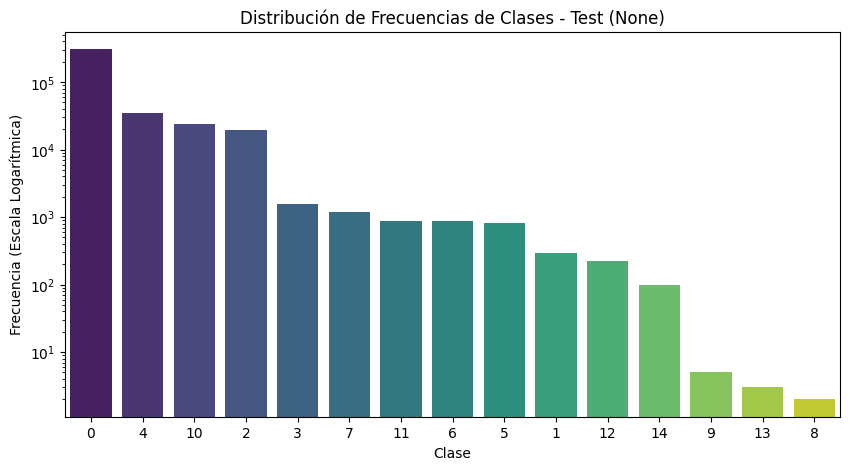

In [20]:
classes, counts = analizar_distribuciones(y_test, "Test (None)")

In [ ]:
def save_confusion_matrix(y_true, y_pred, name, phase="Val"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f'Mixture of Experts - ({phase})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'Logs_MoE_Initial_Arquitecture/{name}.png')
    plt.close()

In [ ]:
from sklearn.metrics import classification_report
import torch

best_dropout = 0.39943101352307636
best_activation = 'leaky_relu'
best_hidden_layers = [192] 

mejor_gating = DynamicGatingNetwork(
    input_dim=input_dim_total, 
    num_experts=6, 
    hidden_layers=best_hidden_layers, 
    dropout_rate=best_dropout, 
    activation_name=best_activation
)

lista_de_expertos = [exp_1, exp_2, exp_3, exp_4, exp_5, exp_6]
mejor_moe_model = OptunaTabularMoE(lista_de_expertos, mejor_gating).to(device)

print("Cargando los pesos del mejor Gating Network con Oversampling SMOTE (Trial 43)...")
mejor_moe_model.load_state_dict(torch.load("Modelos_Gating/Gating_trial_43_smote.pth"))
mejor_moe_model.eval()

y_true_final = []
y_pred_final = []

batch_size_eval = 16384
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
test_loader_moe = TensorDataLoader(X_test, y_test_1d, batch_size=batch_size_eval, shuffle=False)

print("\nEvaluando el Sistema MoE Completo sobre el Set de Validación...")
with torch.no_grad():
    for batch_X, batch_y in val_loader_moe:
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model(batch_X)
        
        _, preds = torch.max(outputs, 1)
        y_true_final.extend(batch_y.cpu().numpy())
        y_pred_final.extend(preds.cpu().numpy())

reporte = classification_report(
    y_true_final, 
    y_pred_final, 
    target_names=[str(c) for c in class_names],
    digits=4
)

print("\nReporte de Clasificacion Mixture of Experts")
print(reporte)

save_confusion_matrix(y_true_final, y_pred_final, "MixtureOfExperts_CM_Antes_TopK_y_Refinamiento_SMOTE")

Cargando los pesos del mejor Gating Network con Oversampling SMOTE (Trial 43)...

Evaluando el Sistema MoE Completo sobre el Set de Validación...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Reporte de Clasificacion Mixture of Experts
                           precision    recall  f1-score   support

                   BENIGN     0.9984    0.9977    0.9980    307072
                      Bot     0.6090    0.5966    0.6027       295
                     DDoS     0.9997    0.9986    0.9992     19204
            DoS GoldenEye     0.9777    0.9929    0.9852      1544
                 DoS Hulk     0.9880    0.9999    0.9939     34661
         DoS Slowhttptest     0.9782    0.9806    0.9794       825
            DoS slowloris     0.9817    0.9896    0.9857       869
              FTP-Patator     0.9958    1.0000    0.9979      1191
               Heartbleed     1.0000    1.0000    1.0000         1
             Infiltration     1.0000    0.6667    0.8000         6
                 PortScan     0.9943    0.9975    0.9959     23839
              SSH-Patator     0.9584    0.9898    0.9739       885
  Web Attack  Brute Force     1.0000    0.0708    0.1322       226
Web Attack  Sql 

In [43]:
#Actualmente tengo un softmax clasico voy a hacer que el modelo seleccione solo a los Top-K expertos y voy a a hacer una Fase de Refinamiento Conjunto con Learning Rate bajo

class OptunaTabularMoEKRouting(nn.Module):
    def __init__(self, lista_expertos, gating_network, top_k_input):
        super(OptunaTabularMoEKRouting, self).__init__()
        self.experts = nn.ModuleList(lista_expertos)
        self.num_experts = len(self.experts)
        self.gating = gating_network
        self.top_k = top_k_input
        for expert in self.experts:
            for param in expert.parameters():
                param.requires_grad = False

    def forward(self, x):
        pesos_gating_soft = self.gating(x)
        
        # Hard Gating
        if self.top_k < self.num_experts:
            topk_values, topk_indices = torch.topk(pesos_gating_soft, k=self.top_k, dim=1)
            mask = torch.zeros_like(pesos_gating_soft).scatter_(1, topk_indices, 1.0)
            pesos_gating = pesos_gating_soft * mask
            pesos_gating = pesos_gating / (pesos_gating.sum(dim=1, keepdim=True) + 1e-9)
        else:
            pesos_gating = pesos_gating_soft

        salidas_expertos = [expert(x) for expert in self.experts] 
        salidas_apiladas = torch.stack(salidas_expertos, dim=1) 
        
        pesos_gating = pesos_gating.unsqueeze(2) 
        salidas_ponderadas = salidas_apiladas * pesos_gating
        
        salida_final = torch.sum(salidas_ponderadas, dim=1) 
        return salida_final
    
def objective_gating_top_k(trial, X_train, y_train, X_val, y_val, input_dim, lista_expertos, oversampling):
    batch_size = trial.suggest_categorical('batch_size', [8192, 16384])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4)
    activation_name = trial.suggest_categorical('activation', ['leaky_relu', 'gelu'])
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    top_k = trial.suggest_int('top_k', 1, 3)
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_layers = []
    base_units = trial.suggest_int('n_units_l0', 64, 512, step=64)
    hidden_layers.append(base_units)
    
    prev_units = base_units
    for i in range(1, n_layers):
        units = trial.suggest_int(f'n_units_l{i}', 64, prev_units, step=64)
        hidden_layers.append(units)
        prev_units = units

    train_loader = TensorDataLoader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = TensorDataLoader(X_val, y_val, batch_size=batch_size*2, shuffle=False)

    # Instancio el Gating y ensamblar el MoE
    gating_net = DynamicGatingNetwork(input_dim, len(lista_expertos), hidden_layers, dropout_rate, activation_name)
    moe_model = OptunaTabularMoEKRouting(lista_expertos, gating_net, top_k).to(device)

    # Optimizador para el Gating Network
    focal_gamma = trial.suggest_float('focal_gamma', 0.0, 5.0) 
    criterion = FocalLoss(gamma=focal_gamma) 
    optimizer = optim.AdamW(moe_model.gating.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.amp.GradScaler('cuda')

    epochs = 50
    best_macro_f1 = 0.0
    patience_counter = 0
    early_stop_patience = 6
    best_model_state = None 

    for epoch in range(epochs):
        moe_model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                outputs = moe_model(batch_X)
                loss = criterion(outputs, batch_y)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
        moe_model.eval()
        y_true_list, y_pred_list = [], []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                with torch.amp.autocast('cuda'):
                    outputs = moe_model(batch_X)
                _, preds = torch.max(outputs, 1)
                y_true_list.append(batch_y)
                y_pred_list.append(preds)
                
        y_true_all = torch.cat(y_true_list).cpu().numpy()
        y_pred_all = torch.cat(y_pred_list).cpu().numpy()
                
        current_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        scheduler.step(current_f1)

        trial.report(current_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
        if current_f1 > best_macro_f1:
            best_macro_f1 = current_f1
            patience_counter = 0
            best_model_state = copy.deepcopy(moe_model.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= early_stop_patience:
            break

    if best_model_state is not None:
        os.makedirs("Modelos_Gating", exist_ok=True)
        ruta_guardado = f"Modelos_Gating/Gating_trial_{trial.number}_{oversampling}.pth"
        torch.save(best_model_state, ruta_guardado)

    return best_macro_f1

In [33]:
print("Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE en Top K Routing...")

input_dim_total = X_train_base.shape[1]

exp_1 = TabularMLP(input_dim_total, hidden_layers=[768, 768, 768], dropout_rate=0.4546740054368903, activation_name='leaky_relu').to(device)

exp_2 = TabularMLP(input_dim_total, hidden_layers=[1024, 1024, 1024, 1024], dropout_rate=0.1081658862089864, activation_name='leaky_relu').to(device)

exp_3 = TabularMLP(input_dim_total, hidden_layers=[1024, 1024, 1024, 1024], dropout_rate=0.1292968837507665, activation_name='leaky_relu').to(device)

exp_4 = TabularMLP(input_dim_total, hidden_layers=[1024, 896], dropout_rate=0.1909959884193678, activation_name='leaky_relu').to(device)

exp_5 = TabularMLP(input_dim_total, hidden_layers=[256, 64], dropout_rate=0.40187265361091173, activation_name='leaky_relu').to(device)

exp_6 = TabularMLP(input_dim_total, hidden_layers=[256, 64, 64, 64], dropout_rate=0.3014571470836104, activation_name='leaky_relu').to(device)

print("Cargando pesos de los expertos...")
exp_1.load_state_dict(torch.load("Modelos_Expertos/Experto_1_trial_79.pth")) 
exp_2.load_state_dict(torch.load("Modelos_Expertos/Experto_2_smote_trial_92.pth"))
exp_3.load_state_dict(torch.load("Modelos_Expertos/Experto_3_smote_trial_96.pth"))
exp_4.load_state_dict(torch.load("Modelos_Expertos/Experto_4_smote_trial_86.pth"))
exp_5.load_state_dict(torch.load("Modelos_Expertos/Experto_5_smote_trial_2.pth"))
exp_6.load_state_dict(torch.load("Modelos_Expertos/Experto_6_smote_trial_2.pth"))
print("Pesos cargados exitosamente sin errores de dimensión.")

lista_de_expertos = [exp_1, exp_2, exp_3, exp_4, exp_5, exp_6]

obj_func_gating_top_k_routing = partial(
    objective_gating_top_k, 
    X_train=X_train_base, 
    y_train=y_train_base, 
    X_val=X_val, 
    y_val=y_val_1d, 
    input_dim=input_dim_total,
    lista_expertos=lista_de_expertos,
    oversampling="smote"
)

study_gating_top_k = optuna.create_study(direction="maximize", study_name="Gating_Optimization_Top_K")
study_gating_top_k.optimize(obj_func_gating_top_k_routing, n_trials=200)

print("\nResultados Optimización Gating Network con Top K Routing")
print(f"Mejor F1 Macro Global: {study_gating_top_k.best_value:.4f}")
print(f"Mejores Hiperparámetros:\n{study_gating_top_k.best_params}")

[I 2026-04-07 01:30:02,131] A new study created in memory with name: Gating_Optimization_Top_K


Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE en Top K Routing...
Cargando pesos de los expertos...
Pesos cargados exitosamente sin errores de dimensión.


[I 2026-04-07 01:30:28,404] Trial 0 finished with value: 0.6925697093742857 and parameters: {'batch_size': 8192, 'dropout_rate': 0.12094120293353036, 'activation': 'leaky_relu', 'lr': 0.0015026752454732324, 'weight_decay': 8.54217633886044e-05, 'top_k': 4, 'n_layers': 1, 'n_units_l0': 384, 'focal_gamma': 4.425796064039523}. Best is trial 0 with value: 0.6925697093742857.
[I 2026-04-07 01:30:34,573] Trial 1 finished with value: 0.7630998341658943 and parameters: {'batch_size': 16384, 'dropout_rate': 0.13647135039819916, 'activation': 'leaky_relu', 'lr': 0.003023523895343993, 'weight_decay': 4.811119546145599e-06, 'top_k': 3, 'n_layers': 1, 'n_units_l0': 192, 'focal_gamma': 2.9328221841949818}. Best is trial 1 with value: 0.7630998341658943.
[I 2026-04-07 01:30:44,526] Trial 2 finished with value: 0.6275342654304571 and parameters: {'batch_size': 8192, 'dropout_rate': 0.13115502477439872, 'activation': 'leaky_relu', 'lr': 0.00012661047461011974, 'weight_decay': 7.531071035754454e-05, 'to


Resultados Optimización Gating Network con Top K Routing
Mejor F1 Macro Global: 0.7730
Mejores Hiperparámetros:
{'batch_size': 16384, 'dropout_rate': 0.2636796443865014, 'activation': 'leaky_relu', 'lr': 0.00046066764512172037, 'weight_decay': 2.3606089535638093e-05, 'top_k': 5, 'n_layers': 1, 'n_units_l0': 448, 'focal_gamma': 2.0668110735731444}


In [38]:
import torch
from sklearn.metrics import f1_score

params_ganadores = study_gating_top_k.best_params
best_dropout = params_ganadores['dropout_rate']
best_activation = params_ganadores['activation']
best_top_k = params_ganadores.get('top_k', 5)

best_hidden_layers = [params_ganadores['n_units_l0']]
if params_ganadores['n_layers'] > 1:
    for i in range(1, params_ganadores['n_layers']):
        best_hidden_layers.append(params_ganadores[f'n_units_l{i}'])

print(f"Reconstruyendo modelo con capas: {best_hidden_layers} y Top-K: {best_top_k}")

mejor_gating = DynamicGatingNetwork(
    input_dim=input_dim_total, 
    num_experts=6, 
    hidden_layers=best_hidden_layers, 
    dropout_rate=best_dropout, 
    activation_name=best_activation
)

lista_de_expertos = [exp_1, exp_2, exp_3, exp_4, exp_5, exp_6]
mejor_moe_model = OptunaTabularMoEKRouting(lista_de_expertos, mejor_gating, best_top_k).to(device)

mejor_trial_num = study_gating_top_k.best_trial.number
ruta_checkpoint = f"Modelos_Gating/Gating_trial_{mejor_trial_num}_smote.pth" 
print(mejor_trial_num)

print(f"Cargando pesos desde: {ruta_checkpoint}")
mejor_moe_model.load_state_dict(torch.load(ruta_checkpoint))

print("\nIniciando Fase de Refinamiento...")

#Descongelar pesos
for param in mejor_moe_model.parameters():
    param.requires_grad = True

batch_size_eval = 8192 
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
train_loader_moe = TensorDataLoader(X_train_base, y_train_base, batch_size=batch_size_eval, shuffle=True)

lr_finetuning = 1e-5 
optimizer_ft = optim.AdamW(mejor_moe_model.parameters(), lr=lr_finetuning, weight_decay=1e-4)

criterion_ft = FocalLoss(gamma=params_ganadores.get('focal_gamma', 2.0)) 
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='max', factor=0.5, patience=2)

scaler = torch.amp.GradScaler('cuda')

epochs_ft = 50
best_macro_f1_ft = 0.0
patience_counter_ft = 0

for epoch in range(epochs_ft):
    mejor_moe_model.train()
    for batch_X, batch_y in train_loader_moe:
        optimizer_ft.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model(batch_X) 
            loss = criterion_ft(outputs, batch_y)
            
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer_ft)
        torch.nn.utils.clip_grad_norm_(mejor_moe_model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer_ft)
        scaler.update()
        
    mejor_moe_model.eval()
    y_true_list, y_pred_list = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader_moe:
            with torch.amp.autocast('cuda'):
                outputs = mejor_moe_model(batch_X)
            _, preds = torch.max(outputs, 1)
            y_true_list.append(batch_y)
            y_pred_list.append(preds)
            
    y_true_all = torch.cat(y_true_list).cpu().numpy()
    y_pred_all = torch.cat(y_pred_list).cpu().numpy()
            
    current_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    scheduler_ft.step(current_f1)
    
    print(f"Época {epoch+1}/{epochs_ft} | Macro F1 Global: {current_f1:.4f}")

Reconstruyendo modelo con capas: [448] y Top-K: 5
38
Cargando pesos desde: Modelos_Gating/Gating_trial_38_smote.pth

Iniciando Fase de Refinamiento...
Época 1/50 | Macro F1 Global: 0.7594
Época 2/50 | Macro F1 Global: 0.7634
Época 3/50 | Macro F1 Global: 0.7549
Época 4/50 | Macro F1 Global: 0.6212
Época 5/50 | Macro F1 Global: 0.7635
Época 6/50 | Macro F1 Global: 0.7637
Época 7/50 | Macro F1 Global: 0.7637
Época 8/50 | Macro F1 Global: 0.7636
Época 9/50 | Macro F1 Global: 0.6173
Época 10/50 | Macro F1 Global: 0.7635
Época 11/50 | Macro F1 Global: 0.7635
Época 12/50 | Macro F1 Global: 0.6873
Época 13/50 | Macro F1 Global: 0.7449
Época 14/50 | Macro F1 Global: 0.7637
Época 15/50 | Macro F1 Global: 0.7635
Época 16/50 | Macro F1 Global: 0.6906
Época 17/50 | Macro F1 Global: 0.7635
Época 18/50 | Macro F1 Global: 0.7634
Época 19/50 | Macro F1 Global: 0.7637
Época 20/50 | Macro F1 Global: 0.7635
Época 21/50 | Macro F1 Global: 0.7636
Época 22/50 | Macro F1 Global: 0.6968
Época 23/50 | Macro F1

In [41]:
from sklearn.metrics import classification_report
import torch

y_true_final = []
y_pred_final = []

batch_size_eval = 16384
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
test_loader_moe = TensorDataLoader(X_test, y_test_1d, batch_size=batch_size_eval, shuffle=False)

print("\nEvaluando el Sistema MoE Completo sobre el Set de Validación...")
with torch.no_grad():
    for batch_X, batch_y in val_loader_moe:
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model(batch_X)
        
        _, preds = torch.max(outputs, 1)
        y_true_final.extend(batch_y.cpu().numpy())
        y_pred_final.extend(preds.cpu().numpy())

reporte = classification_report(
    y_true_final, 
    y_pred_final, 
    target_names=[str(c) for c in class_names],
    digits=4
)

print("\nReporte de Clasificacion Mixture of Experts")
print(reporte)

save_confusion_matrix(y_true_final, y_pred_final, "MixtureOfExperts_CM_Post_TopK_y_Refinamiento")


Evaluando el Sistema MoE Completo sobre el Set de Validación...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Reporte de Clasificacion Mixture of Experts
                           precision    recall  f1-score   support

                   BENIGN     0.9984    0.9984    0.9984    307072
                      Bot     0.9907    0.3627    0.5310       295
                     DDoS     0.9997    0.9995    0.9996     19204
            DoS GoldenEye     0.9909    0.9916    0.9913      1544
                 DoS Hulk     0.9907    0.9999    0.9952     34661
         DoS Slowhttptest     0.9726    0.9903    0.9814       825
            DoS slowloris     0.9896    0.9873    0.9885       869
              FTP-Patator     1.0000    1.0000    1.0000      1191
               Heartbleed     1.0000    1.0000    1.0000         1
             Infiltration     0.8000    0.6667    0.7273         6
                 PortScan     0.9943    0.9992    0.9968     23839
              SSH-Patator     0.9575    0.9932    0.9750       885
  Web Attack  Brute Force     1.0000    0.0929    0.1700       226
Web Attack  Sql 

In [44]:
#Procedo a probar con expertos entrenados con datos sobremuestreados con SMOTE Tomek

print("Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE Tomek...")

input_dim_total = X_train_base.shape[1]

exp_1_tomek = TabularMLP(input_dim_total, hidden_layers=[768, 768, 768], dropout_rate=0.4546740054368903, activation_name='leaky_relu').to(device)

exp_2_tomek = TabularMLP(input_dim_total, hidden_layers=[512, 512, 512, 512], dropout_rate=0.17154912655943821, activation_name='leaky_relu').to(device)

exp_3_tomek = TabularMLP(input_dim_total, hidden_layers=[1024, 896, 256], dropout_rate=0.3533727550531566, activation_name='leaky_relu').to(device)

exp_4_tomek = TabularMLP(input_dim_total, hidden_layers=[1024, 768, 320], dropout_rate=0.1917525589321013, activation_name='leaky_relu').to(device)

exp_5_tomek = TabularMLP(input_dim_total, hidden_layers=[1024, 1024, 1024], dropout_rate=0.2655291358296163, activation_name='leaky_relu').to(device)

exp_6_tomek = TabularMLP(input_dim_total, hidden_layers=[256, 64], dropout_rate=0.20238131647799226, activation_name='leaky_relu').to(device)

print("Cargando pesos de los expertos...")
exp_1_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_1_trial_79.pth")) 
exp_2_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_2_smote_tomek_trial_18.pth"))
exp_3_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_3_smote_tomek_trial_92.pth"))
exp_4_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_4_smote_tomek_trial_1.pth"))
exp_5_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_5_smote_tomek_trial_16.pth"))
exp_6_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_6_smote_tomek_trial_46.pth"))
print("Pesos cargados exitosamente sin errores de dimensión.")

lista_de_expertos_tomek = [exp_1_tomek, exp_2_tomek, exp_3_tomek, exp_4_tomek, exp_5_tomek, exp_6_tomek]

obj_func_gating_tomek = partial(
    objective_gating_top_k, 
    X_train=X_train_base, 
    y_train=y_train_base, 
    X_val=X_val, 
    y_val=y_val_1d, 
    input_dim=input_dim_total,
    lista_expertos=lista_de_expertos_tomek,
    oversampling="smote_tomek"
)

study_gating_tomek = optuna.create_study(direction="maximize", study_name="Gating_Optimization_Tomek")
study_gating_tomek.optimize(obj_func_gating_tomek, n_trials= 200)

print("\nResultados Optimización Gating Network con datos tipo SMOTE Tomek")
print(f"Mejor F1 Macro Global: {study_gating_tomek.best_value:.4f}")
print(f"Mejores Hiperparámetros:\n{study_gating_tomek.best_params}")


[I 2026-04-07 02:41:29,774] A new study created in memory with name: Gating_Optimization_Tomek


Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE Tomek...
Cargando pesos de los expertos...
Pesos cargados exitosamente sin errores de dimensión.


[I 2026-04-07 02:41:40,047] Trial 0 finished with value: 0.2959238653234599 and parameters: {'batch_size': 8192, 'dropout_rate': 0.3280679664303252, 'activation': 'gelu', 'lr': 0.0011283944013150862, 'weight_decay': 0.0009224584467754858, 'top_k': 1, 'n_layers': 3, 'n_units_l0': 256, 'n_units_l1': 64, 'n_units_l2': 64, 'focal_gamma': 4.417553779362508}. Best is trial 0 with value: 0.2959238653234599.
[I 2026-04-07 02:41:45,766] Trial 1 finished with value: 0.7632307004923913 and parameters: {'batch_size': 16384, 'dropout_rate': 0.10604476868583745, 'activation': 'gelu', 'lr': 0.0006439022505236381, 'weight_decay': 5.4990797601949724e-05, 'top_k': 2, 'n_layers': 1, 'n_units_l0': 512, 'focal_gamma': 3.806994754501329}. Best is trial 1 with value: 0.7632307004923913.
[I 2026-04-07 02:41:57,574] Trial 2 finished with value: 0.7590586784771111 and parameters: {'batch_size': 8192, 'dropout_rate': 0.3006016628151633, 'activation': 'gelu', 'lr': 0.00018544877732321245, 'weight_decay': 0.000858


Resultados Optimización Gating Network con datos tipo SMOTE Tomek
Mejor F1 Macro Global: 0.7729
Mejores Hiperparámetros:
{'batch_size': 16384, 'dropout_rate': 0.15323158772537382, 'activation': 'leaky_relu', 'lr': 0.003788947104960011, 'weight_decay': 0.0005841310188679235, 'top_k': 2, 'n_layers': 1, 'n_units_l0': 512, 'focal_gamma': 2.5998763390313098}


In [45]:
import torch
from sklearn.metrics import f1_score

params_ganadores = study_gating_tomek.best_params
best_dropout = params_ganadores['dropout_rate']
best_activation = params_ganadores['activation']
best_top_k = params_ganadores.get('top_k', 5)

best_hidden_layers = [params_ganadores['n_units_l0']]
if params_ganadores['n_layers'] > 1:
    for i in range(1, params_ganadores['n_layers']):
        best_hidden_layers.append(params_ganadores[f'n_units_l{i}'])

print(f"Reconstruyendo modelo con capas: {best_hidden_layers} y Top-K: {best_top_k}")

mejor_gating = DynamicGatingNetwork(
    input_dim=input_dim_total, 
    num_experts=6, 
    hidden_layers=best_hidden_layers, 
    dropout_rate=best_dropout, 
    activation_name=best_activation
)

mejor_moe_model_tomek = OptunaTabularMoEKRouting(lista_de_expertos_tomek, mejor_gating, best_top_k).to(device)

mejor_trial_num = study_gating_tomek.best_trial.number
ruta_checkpoint = f"Modelos_Gating_SMOTE_Tomek/Gating_trial_{mejor_trial_num}_smote_tomek.pth" 
print(mejor_trial_num)

print(f"Cargando pesos desde: {ruta_checkpoint}")
mejor_moe_model_tomek.load_state_dict(torch.load(ruta_checkpoint))

print("\nIniciando Fase de Refinamiento...")

#Descongelar pesos
for param in mejor_moe_model_tomek.parameters():
    param.requires_grad = True

batch_size_eval = 8192 
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
train_loader_moe = TensorDataLoader(X_train_base, y_train_base, batch_size=batch_size_eval, shuffle=True)

lr_finetuning = 1e-5 
optimizer_ft = optim.AdamW(mejor_moe_model_tomek.parameters(), lr=lr_finetuning, weight_decay=1e-4)

criterion_ft = FocalLoss(gamma=params_ganadores.get('focal_gamma', 2.0)) 
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='max', factor=0.5, patience=2)

scaler = torch.amp.GradScaler('cuda')

epochs_ft = 50
best_macro_f1_ft = 0.0
patience_counter_ft = 0

for epoch in range(epochs_ft):
    mejor_moe_model_tomek.train()
    for batch_X, batch_y in train_loader_moe:
        optimizer_ft.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model_tomek(batch_X) 
            loss = criterion_ft(outputs, batch_y)
            
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer_ft)
        torch.nn.utils.clip_grad_norm_(mejor_moe_model_tomek.parameters(), max_norm=1.0)
        
        scaler.step(optimizer_ft)
        scaler.update()
        
    mejor_moe_model_tomek.eval()
    y_true_list, y_pred_list = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader_moe:
            with torch.amp.autocast('cuda'):
                outputs = mejor_moe_model_tomek(batch_X)
            _, preds = torch.max(outputs, 1)
            y_true_list.append(batch_y)
            y_pred_list.append(preds)
            
    y_true_all = torch.cat(y_true_list).cpu().numpy()
    y_pred_all = torch.cat(y_pred_list).cpu().numpy()
            
    current_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    scheduler_ft.step(current_f1)
    
    print(f"Época {epoch+1}/{epochs_ft} | Macro F1 Global: {current_f1:.4f}")

Reconstruyendo modelo con capas: [512] y Top-K: 2
33
Cargando pesos desde: Modelos_Gating_SMOTE_Tomek/Gating_trial_33_smote_tomek.pth

Iniciando Fase de Refinamiento...
Época 1/50 | Macro F1 Global: 0.7590
Época 2/50 | Macro F1 Global: 0.7681
Época 3/50 | Macro F1 Global: 0.7679
Época 4/50 | Macro F1 Global: 0.6966
Época 5/50 | Macro F1 Global: 0.6883
Época 6/50 | Macro F1 Global: 0.7633
Época 7/50 | Macro F1 Global: 0.7635
Época 8/50 | Macro F1 Global: 0.7634
Época 9/50 | Macro F1 Global: 0.6566
Época 10/50 | Macro F1 Global: 0.7635
Época 11/50 | Macro F1 Global: 0.7636
Época 12/50 | Macro F1 Global: 0.7634
Época 13/50 | Macro F1 Global: 0.6968
Época 14/50 | Macro F1 Global: 0.7594
Época 15/50 | Macro F1 Global: 0.6928
Época 16/50 | Macro F1 Global: 0.7636
Época 17/50 | Macro F1 Global: 0.6927
Época 18/50 | Macro F1 Global: 0.6968
Época 19/50 | Macro F1 Global: 0.7636
Época 20/50 | Macro F1 Global: 0.6926
Época 21/50 | Macro F1 Global: 0.7594
Época 22/50 | Macro F1 Global: 0.7635
Époc

In [46]:
from sklearn.metrics import classification_report
import torch

y_true_final = []
y_pred_final = []

batch_size_eval = 16384
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
test_loader_moe = TensorDataLoader(X_test, y_test_1d, batch_size=batch_size_eval, shuffle=False)

print("\nEvaluando el Sistema MoE Completo sobre el Set de Validación...")
with torch.no_grad():
    for batch_X, batch_y in val_loader_moe:
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model_tomek(batch_X)
        
        _, preds = torch.max(outputs, 1)
        y_true_final.extend(batch_y.cpu().numpy())
        y_pred_final.extend(preds.cpu().numpy())

reporte = classification_report(
    y_true_final, 
    y_pred_final, 
    target_names=[str(c) for c in class_names],
    digits=4
)

print("\nReporte de Clasificacion Mixture of Experts Tomek")
print(reporte)

save_confusion_matrix(y_true_final, y_pred_final, "MixtureOfExperts_CM_SMOTE_Tomek_Post_TopK_y_Refinamiento")


Evaluando el Sistema MoE Completo sobre el Set de Validación...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Reporte de Clasificacion Mixture of Experts Tomek
                           precision    recall  f1-score   support

                   BENIGN     0.9984    0.9984    0.9984    307072
                      Bot     0.9907    0.3627    0.5310       295
                     DDoS     0.9997    0.9995    0.9996     19204
            DoS GoldenEye     0.9909    0.9916    0.9913      1544
                 DoS Hulk     0.9910    0.9998    0.9954     34661
         DoS Slowhttptest     0.9784    0.9903    0.9843       825
            DoS slowloris     0.9885    0.9896    0.9891       869
              FTP-Patator     1.0000    1.0000    1.0000      1191
               Heartbleed     1.0000    1.0000    1.0000         1
             Infiltration     0.8000    0.6667    0.7273         6
                 PortScan     0.9943    0.9992    0.9968     23839
              SSH-Patator     0.9575    0.9932    0.9750       885
  Web Attack  Brute Force     1.0000    0.0929    0.1700       226
Web Attack

In [48]:
#Procedo a probar con expertos entrenados con datos sobremuestreados con SMOTE ENN

print("Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE ENN...")

input_dim_total = X_train_base.shape[1]

exp_1_enn = TabularMLP(input_dim_total, hidden_layers=[768, 768, 768], dropout_rate=0.4546740054368903, activation_name='leaky_relu').to(device)

exp_2_enn = TabularMLP(input_dim_total, hidden_layers=[1024,1024], dropout_rate=0.20788364667335843, activation_name='leaky_relu').to(device)

exp_3_enn = TabularMLP(input_dim_total, hidden_layers=[1024, 1024, 1024, 1024], dropout_rate=0.1317813371961186, activation_name='gelu').to(device)

exp_4_enn = TabularMLP(input_dim_total, hidden_layers=[512, 320, 256], dropout_rate=0.10185889336951198, activation_name='leaky_relu').to(device)

exp_5_enn = TabularMLP(input_dim_total, hidden_layers=[512,512,512], dropout_rate=0.33408187919615034, activation_name='leaky_relu').to(device)

exp_6_enn = TabularMLP(input_dim_total, hidden_layers=[256, 256, 256, 256], dropout_rate=0.49220209516561336, activation_name='leaky_relu').to(device)

print("Cargando pesos de los expertos...")
exp_1_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_1_trial_79.pth")) 
exp_2_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_2_smote_enn_trial_78.pth"))
exp_3_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_3_smote_enn_trial_31.pth"))
exp_4_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_4_smote_enn_trial_61.pth"))
exp_5_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_5_smote_enn_trial_66.pth"))
exp_6_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_6_smote_enn_trial_89.pth"))
print("Pesos cargados exitosamente sin errores de dimensión.")

lista_de_expertos_enn = [exp_1_enn, exp_2_enn, exp_3_enn, exp_4_enn, exp_5_enn, exp_6_enn]

obj_func_gating_enn = partial(
    objective_gating_top_k, 
    X_train=X_train_base, 
    y_train=y_train_base, 
    X_val=X_val, 
    y_val=y_val_1d, 
    input_dim=input_dim_total,
    lista_expertos=lista_de_expertos_enn,
    oversampling="smote_enn"
)

study_gating_enn = optuna.create_study(direction="maximize", study_name="Gating_Optimization_ENN")
study_gating_enn.optimize(obj_func_gating_enn, n_trials= 200)

print("\nResultados Optimización Gating Network con datos tipo SMOTE ENN")
print(f"Mejor F1 Macro Global: {study_gating_enn.best_value:.4f}")
print(f"Mejores Hiperparámetros:\n{study_gating_enn.best_params}")


[I 2026-04-07 03:09:09,255] A new study created in memory with name: Gating_Optimization_ENN


Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE ENN...
Cargando pesos de los expertos...
Pesos cargados exitosamente sin errores de dimensión.


[I 2026-04-07 03:09:21,346] Trial 0 finished with value: 0.7548987457264257 and parameters: {'batch_size': 8192, 'dropout_rate': 0.2108297057645217, 'activation': 'gelu', 'lr': 0.0020217220990457726, 'weight_decay': 5.7701758776363195e-05, 'top_k': 3, 'n_layers': 1, 'n_units_l0': 512, 'focal_gamma': 2.4962212129534556}. Best is trial 0 with value: 0.7548987457264257.
[I 2026-04-07 03:09:33,401] Trial 1 finished with value: 0.7546784487117428 and parameters: {'batch_size': 8192, 'dropout_rate': 0.31971656684874583, 'activation': 'gelu', 'lr': 0.004588550724749799, 'weight_decay': 0.0009221864101476455, 'top_k': 3, 'n_layers': 2, 'n_units_l0': 512, 'n_units_l1': 512, 'focal_gamma': 4.121862951981755}. Best is trial 0 with value: 0.7548987457264257.
[I 2026-04-07 03:09:40,786] Trial 2 finished with value: 0.7548095990275694 and parameters: {'batch_size': 8192, 'dropout_rate': 0.11624551934408899, 'activation': 'leaky_relu', 'lr': 0.004831864714571496, 'weight_decay': 3.8677964782755106e-0


Resultados Optimización Gating Network con datos tipo SMOTE ENN
Mejor F1 Macro Global: 0.7678
Mejores Hiperparámetros:
{'batch_size': 16384, 'dropout_rate': 0.3343740557259049, 'activation': 'gelu', 'lr': 0.0005470675151255103, 'weight_decay': 0.00040135605666944806, 'top_k': 3, 'n_layers': 3, 'n_units_l0': 448, 'n_units_l1': 384, 'n_units_l2': 384, 'focal_gamma': 1.3441876936696966}


In [49]:
import torch
from sklearn.metrics import f1_score

params_ganadores = study_gating_enn.best_params
best_dropout = params_ganadores['dropout_rate']
best_activation = params_ganadores['activation']
best_top_k = params_ganadores.get('top_k')

best_hidden_layers = [params_ganadores['n_units_l0']]
if params_ganadores['n_layers'] > 1:
    for i in range(1, params_ganadores['n_layers']):
        best_hidden_layers.append(params_ganadores[f'n_units_l{i}'])

print(f"Reconstruyendo modelo con capas: {best_hidden_layers} y Top-K: {best_top_k}")

mejor_gating = DynamicGatingNetwork(
    input_dim=input_dim_total, 
    num_experts=6, 
    hidden_layers=best_hidden_layers, 
    dropout_rate=best_dropout, 
    activation_name=best_activation
)

mejor_moe_model_enn = OptunaTabularMoEKRouting(lista_de_expertos_enn, mejor_gating, best_top_k).to(device)

mejor_trial_num = study_gating_enn.best_trial.number
ruta_checkpoint = f"Modelos_Gating_SMOTE_ENN/Gating_trial_{mejor_trial_num}_smote_enn.pth" 
print(mejor_trial_num)

print(f"Cargando pesos desde: {ruta_checkpoint}")
mejor_moe_model_enn.load_state_dict(torch.load(ruta_checkpoint))

print("\nIniciando Fase de Refinamiento...")

#Descongelar pesos
for param in mejor_moe_model_enn.parameters():
    param.requires_grad = True

batch_size_eval = 8192 
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
train_loader_moe = TensorDataLoader(X_train_base, y_train_base, batch_size=batch_size_eval, shuffle=True)

lr_finetuning = 1e-5 
optimizer_ft = optim.AdamW(mejor_moe_model_enn.parameters(), lr=lr_finetuning, weight_decay=1e-4)

criterion_ft = FocalLoss(gamma=params_ganadores.get('focal_gamma', 2.0)) 
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='max', factor=0.5, patience=2)

scaler = torch.amp.GradScaler('cuda')

epochs_ft = 50
best_macro_f1_ft = 0.0
patience_counter_ft = 0

for epoch in range(epochs_ft):
    mejor_moe_model_enn.train()
    for batch_X, batch_y in train_loader_moe:
        optimizer_ft.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model_enn(batch_X) 
            loss = criterion_ft(outputs, batch_y)
            
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer_ft)
        torch.nn.utils.clip_grad_norm_(mejor_moe_model_enn.parameters(), max_norm=1.0)
        
        scaler.step(optimizer_ft)
        scaler.update()
        
    mejor_moe_model_enn.eval()
    y_true_list, y_pred_list = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader_moe:
            with torch.amp.autocast('cuda'):
                outputs = mejor_moe_model_enn(batch_X)
            _, preds = torch.max(outputs, 1)
            y_true_list.append(batch_y)
            y_pred_list.append(preds)
            
    y_true_all = torch.cat(y_true_list).cpu().numpy()
    y_pred_all = torch.cat(y_pred_list).cpu().numpy()
            
    current_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    scheduler_ft.step(current_f1)
    
    print(f"Época {epoch+1}/{epochs_ft} | Macro F1 Global: {current_f1:.4f}")

Reconstruyendo modelo con capas: [448, 384, 384] y Top-K: 3
23
Cargando pesos desde: Modelos_Gating_SMOTE_ENN/Gating_trial_23_smote_enn.pth

Iniciando Fase de Refinamiento...
Época 1/50 | Macro F1 Global: 0.7547
Época 2/50 | Macro F1 Global: 0.7546
Época 3/50 | Macro F1 Global: 0.7633
Época 4/50 | Macro F1 Global: 0.7632
Época 5/50 | Macro F1 Global: 0.7632
Época 6/50 | Macro F1 Global: 0.7592
Época 7/50 | Macro F1 Global: 0.7632
Época 8/50 | Macro F1 Global: 0.6331
Época 9/50 | Macro F1 Global: 0.7633
Época 10/50 | Macro F1 Global: 0.7632
Época 11/50 | Macro F1 Global: 0.7632
Época 12/50 | Macro F1 Global: 0.7628
Época 13/50 | Macro F1 Global: 0.7634
Época 14/50 | Macro F1 Global: 0.7593
Época 15/50 | Macro F1 Global: 0.7593
Época 16/50 | Macro F1 Global: 0.7633
Época 17/50 | Macro F1 Global: 0.7632
Época 18/50 | Macro F1 Global: 0.7632
Época 19/50 | Macro F1 Global: 0.7633
Época 20/50 | Macro F1 Global: 0.7637
Época 21/50 | Macro F1 Global: 0.7636
Época 22/50 | Macro F1 Global: 0.759

In [50]:
from sklearn.metrics import classification_report
import torch

y_true_final = []
y_pred_final = []

batch_size_eval = 16384
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
test_loader_moe = TensorDataLoader(X_test, y_test_1d, batch_size=batch_size_eval, shuffle=False)

print("\nEvaluando el Sistema MoE Completo sobre el Set de Validación...")
with torch.no_grad():
    for batch_X, batch_y in val_loader_moe:
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model_enn(batch_X)
        
        _, preds = torch.max(outputs, 1)
        y_true_final.extend(batch_y.cpu().numpy())
        y_pred_final.extend(preds.cpu().numpy())

reporte = classification_report(
    y_true_final, 
    y_pred_final, 
    target_names=[str(c) for c in class_names],
    digits=4
)

print("\nReporte de Clasificacion Mixture of Experts SMOTE ENN")
print(reporte)

save_confusion_matrix(y_true_final, y_pred_final, "MixtureOfExperts_CM_SMOTE_ENN_Post_TopK_y_Refinamiento")


Evaluando el Sistema MoE Completo sobre el Set de Validación...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Reporte de Clasificacion Mixture of Experts SMOTE ENN
                           precision    recall  f1-score   support

                   BENIGN     0.9984    0.9983    0.9983    307072
                      Bot     0.9907    0.3627    0.5310       295
                     DDoS     0.9996    0.9995    0.9995     19204
            DoS GoldenEye     0.9871    0.9922    0.9897      1544
                 DoS Hulk     0.9899    0.9999    0.9949     34661
         DoS Slowhttptest     0.9773    0.9903    0.9837       825
            DoS slowloris     0.9862    0.9896    0.9879       869
              FTP-Patator     0.9975    0.9992    0.9983      1191
               Heartbleed     1.0000    1.0000    1.0000         1
             Infiltration     0.6667    0.6667    0.6667         6
                 PortScan     0.9943    0.9992    0.9968     23839
              SSH-Patator     0.9573    0.9887    0.9728       885
  Web Attack  Brute Force     1.0000    0.0929    0.1700       226
Web At